In [33]:
## các thư viện sử dụng
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time as t

## Các file có trong tệp data
- `application_train.csv / application_test.csv` : Chứa thông tin hồ sơ khách hàng (nhân khẩu học, thu nhập, tình trạng hôn nhân, nghề nghiệp, v.v.).

- `bureau.csv`: Dữ liệu về các khoản vay trước đây của khách hàng tại các tổ chức tín dụng khác (ngoài Home Credit). Bao gồm tình trạng hợp đồng, ngày mở/đóng, số tiền vay, tình trạng quá hạn.

- `bureau_balance.csv` : Bảng chi tiết theo tháng về tình trạng các khoản vay trong bureau.csv (ví dụ: tình trạng hợp đồng từng tháng, có quá hạn hay không).

- `credit_card_balance.csv`: Lịch sử giao dịch thẻ tín dụng của khách hàng: dư nợ, hạn mức, số lần quá hạn, số tháng thanh toán.

- `POS_CASH_balance.csv `: Lịch sử các khoản vay trả góp tại điểm bán (POS) hoặc tiền mặt. Theo dõi trạng thái hợp đồng từng tháng.

- `installments_payments.csv` : Thông tin về các khoản trả góp: số tiền phải trả, số tiền thực trả, ngày trả, có trả đúng hạn hay không.

- `previous_application.csv`: Các khoản vay mà khách hàng đã đăng ký trước đây tại Home Credit (có được chấp nhận hay từ chối, số tiền vay, mục đích vay).

- `HomeCredit_columns_description.csv` : File mô tả chi tiết ý nghĩa của từng cột trong các bảng trên.

- `sample_submission.csv `: File mẫu để nộp kết quả dự đoán (dùng trong Kaggle competition).


In [34]:
# Đường dẫn của data
application_train_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/application_train.csv'
application_test_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/application_test.csv'
bureau_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/bureau.csv'
credit_card_balance_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/credit_card_balance.csv'
pos_cash_balance_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/POS_CASH_balance.csv'
installment_payments_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/installments_payments.csv'
previous_application_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/previous_application.csv'
HomeCredit_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/HomeCredit_columns_description.csv'


## Đọc Data từ transaction_data_path và identity_data_path

In [35]:
# Đọc data từ transaction_data_path
start_time = t.time()

application_train = pd.read_csv(application_train_path)
bureau = pd.read_csv(bureau_path)
credit_card_balance = pd.read_csv(credit_card_balance_path)
pos_cash_balance = pd.read_csv(pos_cash_balance_path)
installment_payments = pd.read_csv(installment_payments_path)
previous_application = pd.read_csv(previous_application_path)
HomeCredit_path = pd.read_csv(HomeCredit_path,encoding='latin-1') # do file này có chứa các ký tự đặc biệt nên cần thêm encoding='latin-1' để đọc dữ liệu
end_time = t.time()
print(f'Thời gian đọc dữ liệu là: {end_time - start_time} giây')

Thời gian đọc dữ liệu là: 82.53394627571106 giây


## Hàm phân tích tổng quan cho từng tập data

In [36]:
# Hàm tiện ích để hiển thị thông tin cơ bản của dataframe
def display_dataframe_info(df):
    print('Kiểm tra cấu trúc của dataframe:')
    print('Show ra 5 dòng đầu tiên trong dataframe:')
    print('---'*30)
    print(df.head())
    print('---'*30)
    print('Số lượng dòng và cột:', df.shape)
    print('---'*30)
    print('Thông tin chi tiết của dataframe:')
    print(df.info())
    print('---'*30)
    print('Các cột có trong datafarme:', df.columns)
    print('---'*30)
    print('Thống kê tổng quát data:')
    print(df.describe())


#----------------------------------------------------------
# kiểm tra giá trị bị thiếu
def check_missing_values(df, sort_by="count", ascending=False):
    print('Kiểm tra giá trị bị thiếu trong dataframe:')
    
    # Tạo dataframe chứa thông tin missing
    missing_info = []
    for col in df.columns:
        missing_val = df[col].isnull().sum()
        percent = (missing_val / len(df[col])) * 100
        missing_info.append([col, missing_val, percent])
    
    # Chuyển sang DataFrame để dễ sort
    missing_df = pd.DataFrame(missing_info, columns=["Column", "MissingCount", "MissingPercent"])
    
    # Sắp xếp theo yêu cầu
    if sort_by == "count":
        missing_df = missing_df.sort_values(by="MissingCount", ascending=ascending)
    elif sort_by == "percent":
        missing_df = missing_df.sort_values(by="MissingPercent", ascending=ascending)
    
    # In kết quả
    for _, row in missing_df.iterrows():
        print(f"Cột {row['Column']} có \033[4m{row['MissingCount']}\033[0m missing values "
              f"và chiếm \033[4m{row['MissingPercent']:.2f}%\033[0m")
        
#----------------------------------------------------------
# kiểm tra giá trị bị trùng lập
def check_duplicateted(df):
    print('Kiểm tra giá trị bị trùng lặp trong dataframe:')
    print(df.duplicated().sum())
#----------------------------------------------------------
def check_unique_values(df):
    print('Kiểm tra giá trị duy nhất trong dataframe:')
    for col in df.columns:
        unique_count = df[col].nunique()
        print(f"Cột {col} có \033[4m{unique_count}\033[0m giá trị duy nhất.")
#----------------------------------------------------------
# kiểm tra mối tương quan giữa các cột
def check_corr(df):
    print('Kiểm tra mối tương quan giữa các cột trong dataframe:')
    df_numeric = df.select_dtypes(include='number')
    corr_matrix = df_numeric.corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f")
    plt.title('Correlation Matrix')
    plt.show()
#----------------------------------------------------------
# kiểm tra sự cân bằng của biến mục tiêu
def check_target_balance(df, target_col):
    print(f'Kiểm tra sự cân bằng của biến mục tiêu: {target_col}')
    counts = df[target_col].value_counts(normalize=True)
    print(counts)
#----------------------------------------------------------
# kiểm tra phân phối của các biến số
def check_skewness(df):
    numeric_cols = df.select_dtypes(include='number').columns
    skew_df = df[numeric_cols].skew().sort_values(ascending=False)
    print(f'Độ lệch của các cột số (càng cao càng lệch):')
    print(skew_df)

In [37]:
display_dataframe_info(application_train)


Kiểm tra cấu trúc của dataframe:
Show ra 5 dòng đầu tiên trong dataframe:
------------------------------------------------------------------------------------------
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             

# Cấu trúc dữ liệu dự án Home Credit

Dưới đây là phân loại các nhóm đặc trưng (features) trong tập dữ liệu `application_train.csv`.

## 1. Nhóm Định danh & Mục tiêu (Target)
- `SK_ID_CURR`: ID khách hàng (khóa chính để liên kết dữ liệu).
- `TARGET`: **Biến mục tiêu**. 
    - `1`: Khách hàng gặp khó khăn thanh toán (Nợ xấu).
    - `0`: Khách hàng trả nợ đúng hạn.

## 2. Nhóm Thông tin cá nhân (Nhân khẩu học)
Mô tả chi tiết về hồ sơ khách hàng:
- **Cơ bản**: `CODE_GENDER` (Giới tính), `CNT_CHILDREN` (Số lượng con), `NAME_FAMILY_STATUS` (Tình trạng hôn nhân).
- **Thời gian**: `DAYS_BIRTH` (Tuổi), `DAYS_ID_PUBLISH` (Thời điểm cấp CCCD).
- **Giáo dục & Công việc**: `NAME_EDUCATION_TYPE` (Học vấn), `NAME_INCOME_TYPE` (Nguồn thu nhập), `OCCUPATION_TYPE` (Nghề nghiệp), `ORGANIZATION_TYPE` (Loại hình tổ chức).

## 3. Nhóm Tình trạng tài chính (Khả năng chi trả)
Xác định năng lực tài chính của khách hàng:
- **Thu nhập & Khoản vay**: `AMT_INCOME_TOTAL` (Tổng thu nhập), `AMT_CREDIT` (Tổng số tiền vay), `AMT_ANNUITY` (Số tiền trả góp hàng tháng).
- **Tài sản**: `NAME_HOUSING_TYPE` (Loại nhà ở), `FLAG_OWN_REALTY` (Sở hữu bất động sản).

## 4. Nhóm Dữ liệu từ bên thứ ba (EXT_SOURCE)
- `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`: Các điểm số tín dụng tổng hợp từ các nguồn dữ liệu bên ngoài. 
    - > **Lưu ý**: Đây là nhóm biến có khả năng dự báo mạnh nhất cho mô hình.

## 5. Nhóm Kỹ thuật & Lịch sử tín dụng
- **Thông tin liên lạc**: `REGION_RATING_CLIENT` (Đánh giá khu vực cư trú), `FLAG_PHONE`, `FLAG_EMAIL`.
- **Lịch sử yêu cầu**: `AMT_REQ_CREDIT_BUREAU_...` (Số lần hỏi vay trong các khung thời gian từ giờ đến năm).
    - > *Insight*: Tần suất hỏi vay cao liên tục trong thời gian ngắn thường là dấu hiệu của rủi ro tài chính.

## 6. Nhóm thông tin bổ sung (Dữ liệu "thô")
- **Thông tin bất động sản**: `APARTMENTS_AVG`, `LIVINGAREA_AVG`, `FLOORSMAX_AVG`... (Mô tả chi tiết căn nhà khách hàng đang ở).
- **Giấy tờ xác thực**: `FLAG_DOCUMENT_2` đến `FLAG_DOCUMENT_21` (Các loại tài liệu khách hàng đã cung cấp cho tổ chức tín dụng).

In [38]:
check_missing_values(application_train, sort_by="count", ascending=False)

Kiểm tra giá trị bị thiếu trong dataframe:
Cột COMMONAREA_AVG có 214865 missing values và chiếm 69.87%
Cột COMMONAREA_MODE có 214865 missing values và chiếm 69.87%
Cột COMMONAREA_MEDI có 214865 missing values và chiếm 69.87%
Cột NONLIVINGAPARTMENTS_MEDI có 213514 missing values và chiếm 69.43%
Cột NONLIVINGAPARTMENTS_MODE có 213514 missing values và chiếm 69.43%
Cột NONLIVINGAPARTMENTS_AVG có 213514 missing values và chiếm 69.43%
Cột FONDKAPREMONT_MODE có 210295 missing values và chiếm 68.39%
Cột LIVINGAPARTMENTS_AVG có 210199 missing values và chiếm 68.35%
Cột LIVINGAPARTMENTS_MEDI có 210199 missing values và chiếm 68.35%
Cột LIVINGAPARTMENTS_MODE có 210199 missing values và chiếm 68.35%
Cột FLOORSMIN_MODE có 208642 missing values và chiếm 67.85%
Cột FLOORSMIN_AVG có 208642 missing values và chiếm 67.85%
Cột FLOORSMIN_MEDI có 208642 missing values và chiếm 67.85%
Cột YEARS_BUILD_AVG có 204488 missing values và chiếm 66.50%
Cột YEARS_BUILD_MODE có 204488 missing values và chiếm 66.50%


C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\2491890821.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df.values, palette="viridis")


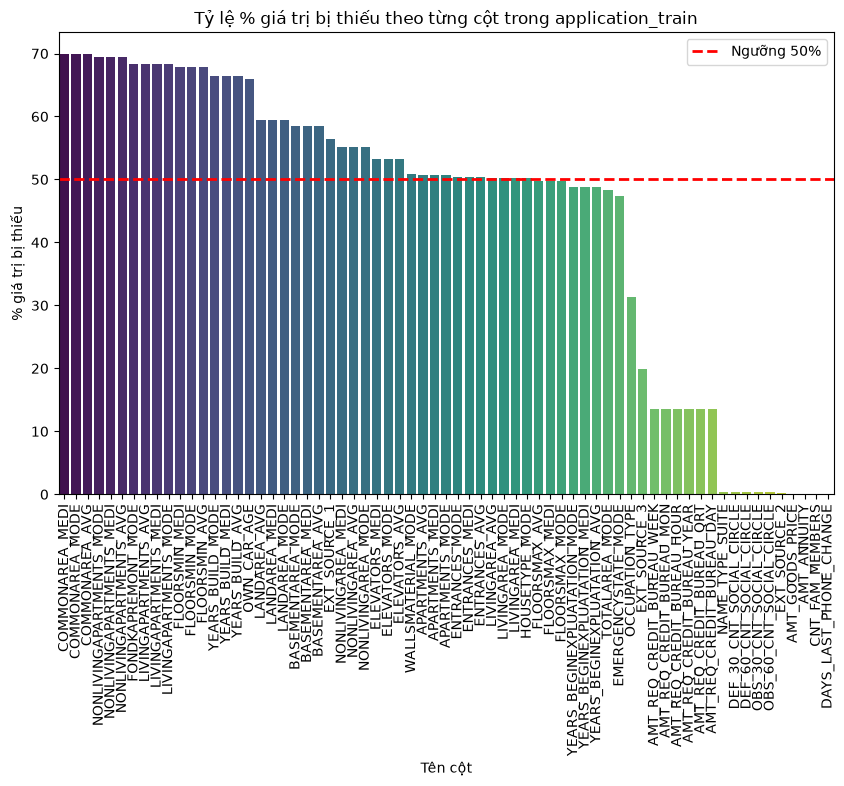

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\2491890821.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_missing_df.index, y=high_missing_df.values, palette="magma")


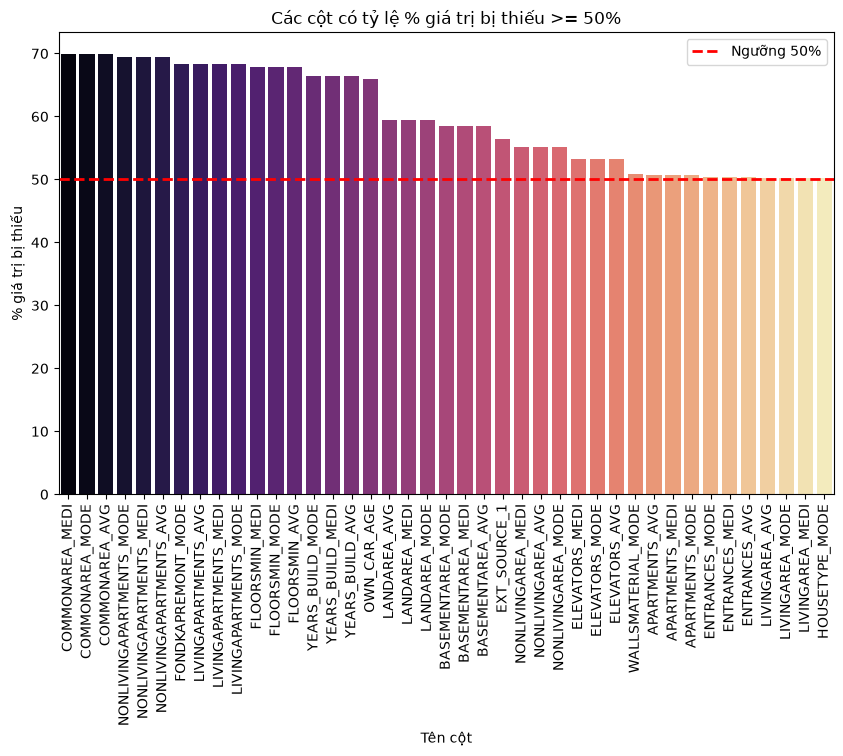

Các cột có tỷ lệ % giá trị bị thiếu >= 50%:
- COMMONAREA_MEDI: 69.87%
- COMMONAREA_MODE: 69.87%
- COMMONAREA_AVG: 69.87%
- NONLIVINGAPARTMENTS_MODE: 69.43%
- NONLIVINGAPARTMENTS_MEDI: 69.43%
- NONLIVINGAPARTMENTS_AVG: 69.43%
- FONDKAPREMONT_MODE: 68.39%
- LIVINGAPARTMENTS_AVG: 68.35%
- LIVINGAPARTMENTS_MEDI: 68.35%
- LIVINGAPARTMENTS_MODE: 68.35%
- FLOORSMIN_MEDI: 67.85%
- FLOORSMIN_MODE: 67.85%
- FLOORSMIN_AVG: 67.85%
- YEARS_BUILD_MODE: 66.50%
- YEARS_BUILD_MEDI: 66.50%
- YEARS_BUILD_AVG: 66.50%
- OWN_CAR_AGE: 65.99%
- LANDAREA_AVG: 59.38%
- LANDAREA_MEDI: 59.38%
- LANDAREA_MODE: 59.38%
- BASEMENTAREA_MODE: 58.52%
- BASEMENTAREA_MEDI: 58.52%
- BASEMENTAREA_AVG: 58.52%
- EXT_SOURCE_1: 56.38%
- NONLIVINGAREA_MEDI: 55.18%
- NONLIVINGAREA_AVG: 55.18%
- NONLIVINGAREA_MODE: 55.18%
- ELEVATORS_MEDI: 53.30%
- ELEVATORS_MODE: 53.30%
- ELEVATORS_AVG: 53.30%
- WALLSMATERIAL_MODE: 50.84%
- APARTMENTS_AVG: 50.75%
- APARTMENTS_MEDI: 50.75%
- APARTMENTS_MODE: 50.75%
- ENTRANCES_MODE: 50.35%
- ENTRA

In [39]:
# Tính số lượng và phần trăm giá trị thiếu theo từng cột
missing_values = application_train.isnull().sum()
missing_percent = 100 * missing_values / len(application_train)

# Lọc ra cột có dữ liệu thiếu
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_df.index, y=missing_df.values, palette="viridis")
plt.xticks(rotation=90)
plt.ylabel('% giá trị bị thiếu')
plt.xlabel('Tên cột')
plt.title('Tỷ lệ % giá trị bị thiếu theo từng cột trong application_train')
plt.xlim(-0.5, len(missing_df)-0.5)
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Ngưỡng 50%')
plt.legend()
plt.show()

# Biểu đồ riêng cho các cột có tỷ lệ thiếu >= 50%
high_missing_df = missing_df[missing_df >= 50]

plt.figure(figsize=(10, 6))
sns.barplot(x=high_missing_df.index, y=high_missing_df.values, palette="magma")
plt.xticks(rotation=90)
plt.ylabel('% giá trị bị thiếu')
plt.xlabel('Tên cột')
plt.title('Các cột có tỷ lệ % giá trị bị thiếu >= 50%')
plt.xlim(-0.5, len(high_missing_df)-0.5)
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Ngưỡng 50%')
plt.legend()
plt.show()


print("Các cột có tỷ lệ % giá trị bị thiếu >= 50%:")
for col in high_missing_df.index:
    print(f"- {col}: {high_missing_df[col]:.2f}%")

### Chú thích 
1. Mục tiêu biểu đồ
    - Biểu đồ được tạo ra nhằm kiểm tra tỷ lệ dữ liệu bị thiếu theo từng cột.
    - Từ đó, ta có thể đánh giá chất lượng tập dữ liệu và đưa ra quyết định xử lý phù hợp (loại bỏ, thay thế, hoặc giữ lại).

2. Vấn đề phát hiện
    - Kết quả cho thấy có nhiều cột có tỷ lệ dữ liệu thiếu trên 50%.
    - Đây là một dấu hiệu nghiêm trọng, vì dữ liệu thiếu quá nhiều sẽ làm giảm độ tin cậy của mô hình dự đoán.
    - Nếu giữ nguyên, mô hình có thể bị thiên lệch, giảm độ chính xác, hoặc thậm chí không học được thông tin hữu ích.

3. Giải thích ý nghĩa
    - Các cột vượt ngưỡng 50% thường được coi là không đủ thông tin để sử dụng.
    - Việc xử lý có thể theo hướng:
        - Loại bỏ cột: nếu dữ liệu thiếu quá nhiều và không thể bổ sung.
        - Thay thế giá trị: nếu cột quan trọng, có thể dùng giá trị trung bình, median, hoặc mô hình dự đoán để điền.

    - Đường ngang màu đỏ ở mức 50% trong biểu đồ chính là ngưỡng cảnh báo để dễ dàng nhận diện.

In [40]:
check_duplicateted(application_train)

Kiểm tra giá trị bị trùng lặp trong dataframe:
0


C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\4226181608.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Column', y='UniqueCount', data=unique_df, palette="viridis")


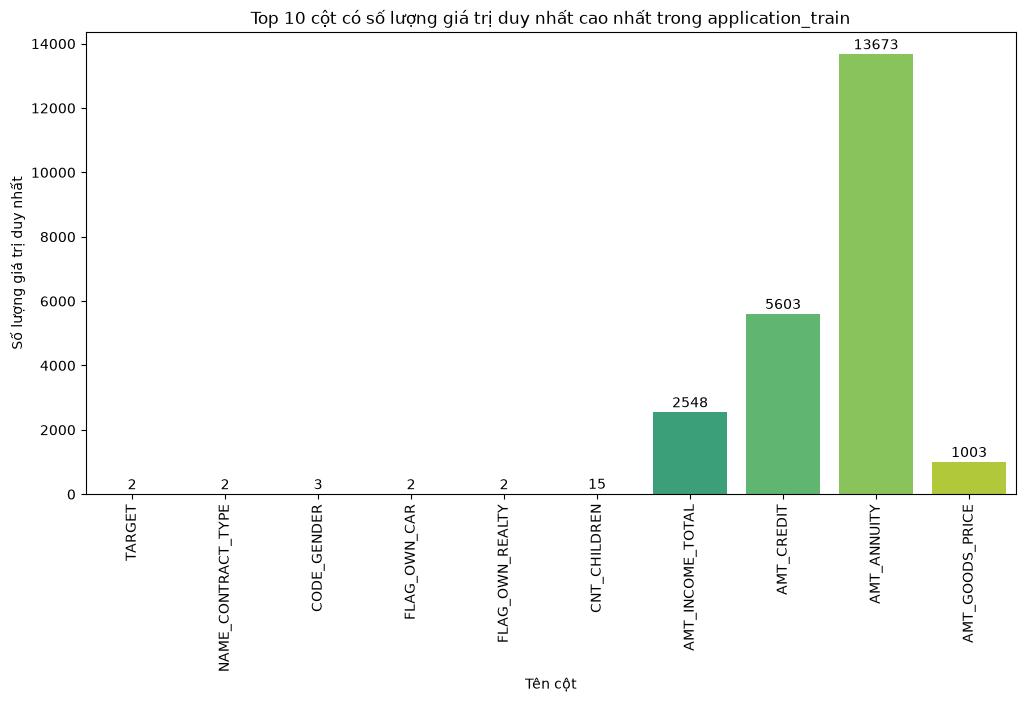

In [41]:
# biểu đồ thể hiện giá trị duy nhất của từng cột trong dataframe
unique_df = pd.DataFrame({'Column': application_train.columns, 
                          'UniqueCount': [len(application_train[col].unique()) 
                                          for col in application_train.columns]})
unique_df = unique_df.iloc[1:11]  # Lấy 10 cột có số lượng giá trị duy nhất cao nhất

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Column', y='UniqueCount', data=unique_df, palette="viridis")

plt.xticks(rotation=90)
plt.ylabel('Số lượng giá trị duy nhất')
plt.xlabel('Tên cột')
plt.title('Top 10 cột có số lượng giá trị duy nhất cao nhất trong application_train')

# Hiển thị giá trị trên mỗi cột
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2,   # vị trí ngang (giữa cột)
            p.get_height() + 50,           # vị trí dọc (cao hơn cột một chút)
            int(p.get_height()),           # giá trị hiển thị
            ha='center', va='bottom', fontsize=10, color='black')

plt.show()

In [42]:
check_unique_values(application_train)

Kiểm tra giá trị duy nhất trong dataframe:
Cột SK_ID_CURR có 307511 giá trị duy nhất.
Cột TARGET có 2 giá trị duy nhất.
Cột NAME_CONTRACT_TYPE có 2 giá trị duy nhất.
Cột CODE_GENDER có 3 giá trị duy nhất.
Cột FLAG_OWN_CAR có 2 giá trị duy nhất.
Cột FLAG_OWN_REALTY có 2 giá trị duy nhất.
Cột CNT_CHILDREN có 15 giá trị duy nhất.
Cột AMT_INCOME_TOTAL có 2548 giá trị duy nhất.
Cột AMT_CREDIT có 5603 giá trị duy nhất.
Cột AMT_ANNUITY có 13672 giá trị duy nhất.
Cột AMT_GOODS_PRICE có 1002 giá trị duy nhất.
Cột NAME_TYPE_SUITE có 7 giá trị duy nhất.
Cột NAME_INCOME_TYPE có 8 giá trị duy nhất.
Cột NAME_EDUCATION_TYPE có 5 giá trị duy nhất.
Cột NAME_FAMILY_STATUS có 6 giá trị duy nhất.
Cột NAME_HOUSING_TYPE có 6 giá trị duy nhất.
Cột REGION_POPULATION_RELATIVE có 81 giá trị duy nhất.
Cột DAYS_BIRTH có 17460 giá trị duy nhất.
Cột DAYS_EMPLOYED có 12574 giá trị duy nhất.
Cột DAYS_REGISTRATION có 15688 giá trị duy nhất.
Cột DAYS_ID_PUBLISH có 6168 giá trị duy nhất.
Cột OWN_CAR_AGE có 62 giá trị du

In [43]:
check_target_balance(application_train, 'TARGET')

Kiểm tra sự cân bằng của biến mục tiêu: TARGET
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [ ]:
check_skewness(application_train)

Độ lệch của các cột số (càng cao càng lệch):
FLAG_DOCUMENT_12                392.114779
AMT_INCOME_TOTAL                391.559654
FLAG_DOCUMENT_10                209.589054
FLAG_DOCUMENT_2                 153.791817
AMT_REQ_CREDIT_BUREAU_QRT       134.365776
                                   ...    
YEARS_BEGINEXPLUATATION_MODE    -14.755318
YEARS_BEGINEXPLUATATION_AVG     -15.515264
YEARS_BEGINEXPLUATATION_MEDI    -15.573124
FLAG_CONT_MOBILE                -23.081172
FLAG_MOBIL                     -554.536744
Length: 106, dtype: float64


# Tìm hiểu sâu hơn vào tập data

## Phần thông tin khách hàng
- CODE_GENDER: Giới tính.
- CNT_CHILDREN: Số lượng con cái.
    - DAYS_BIRTH: Tuổi của khách hàng (đơn vị: ngày, tính ngược từ thời điểm hiện tại).
    - NAME_FAMILY_STATUS: Tình trạng hôn nhân.
    - NAME_EDUCATION_TYPE: Trình độ học vấn.

### 1 Cột giới tính
- Kiểm tra tổng quan cột df.describe()
- Kiểm tra dũ liệu bị thiếu
- Phân tích tỉ lệ giới tính 
- Tỷ lệ giới tính gian lận

In [45]:
application_train['CODE_GENDER'].describe()

count     307511
unique         3
top            F
freq      202448
Name: CODE_GENDER, dtype: object

In [46]:
application_train['CODE_GENDER'].unique()

<StringArray>
['M', 'F', 'XNA']
Length: 3, dtype: str

In [47]:
application_train['CODE_GENDER'].isnull().sum()

np.int64(0)

Biểu đồ phân phối giá trị giới tính trong data
Số lượng các giá trị của mỗi thành phần trong cột CODE_GENDER:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64


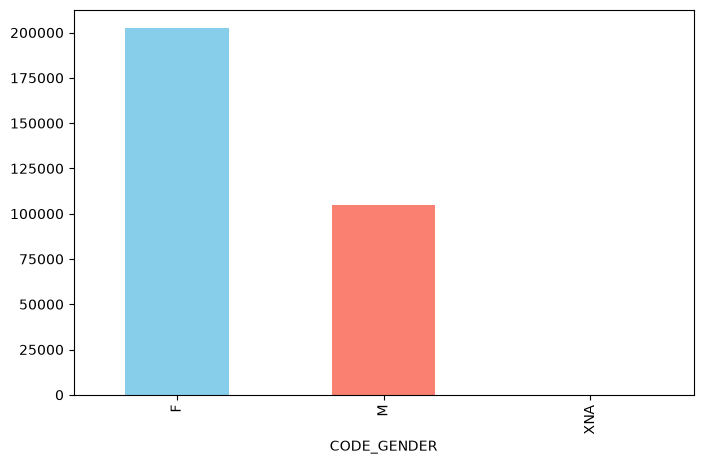

In [48]:
application_train['CODE_GENDER'].value_counts().plot(kind='bar', figsize=(8, 5), color=['skyblue', 'salmon'])
print("Biểu đồ phân phối giá trị giới tính trong data")
print("Số lượng các giá trị của mỗi thành phần trong cột CODE_GENDER:")
print(application_train['CODE_GENDER'].value_counts())

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\489091124.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CODE_GENDER', data=df_fraud, palette="viridis")


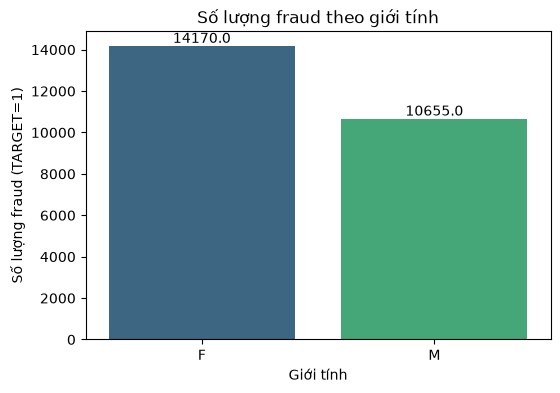

In [49]:
df = application_train[['CODE_GENDER', 'TARGET']]
df_female_fraud= df[(df['CODE_GENDER'] == 'F') & (df['TARGET'] == 1)]
df_male_fraud= df[(df['CODE_GENDER'] == 'M') & (df['TARGET'] == 1)]
df_fraud = pd.concat([df_female_fraud, df_male_fraud], axis=0)

# Vẽ biểu đồ số lượng fraud theo giới tính
plt.figure(figsize=(6, 4))
sns.countplot(x='CODE_GENDER', data=df_fraud, palette="viridis")

plt.xlabel('Giới tính')
plt.ylabel('Số lượng fraud (TARGET=1)')
plt.title('Số lượng fraud theo giới tính')

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), 
                       textcoords='offset points')
plt.show()

 - Biểu đồ 1 và 2 được tạo nên với mục đích kiểm tra xem giới tính nào sở hữu thẻ tính dụng nhiều nhất và có số lượng không có khả năng chi trả lớn nhất
 - Biểu đồ cho thấy nữ giới sở hữu nữ giới và không có khả năng chi trả khoảng vay
    - Lý do mà nữ giới có tỉ lệ không thể chi trả cao hơn là nam có thể là do hành mua sắm, trang điểm, ăn uống (đa số sẽ là đồ dắt tiền)
    

### Phân tích cột CNT_CHILDREN: Số lượng con cái. 

In [50]:
df = application_train['CNT_CHILDREN']

In [51]:
df.describe()

count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64

In [52]:
df.isnull().sum()

np.int64(0)

In [53]:
df.unique()

array([ 0,  1,  2,  3,  4,  7,  5,  6,  8,  9, 11, 12, 10, 19, 14])

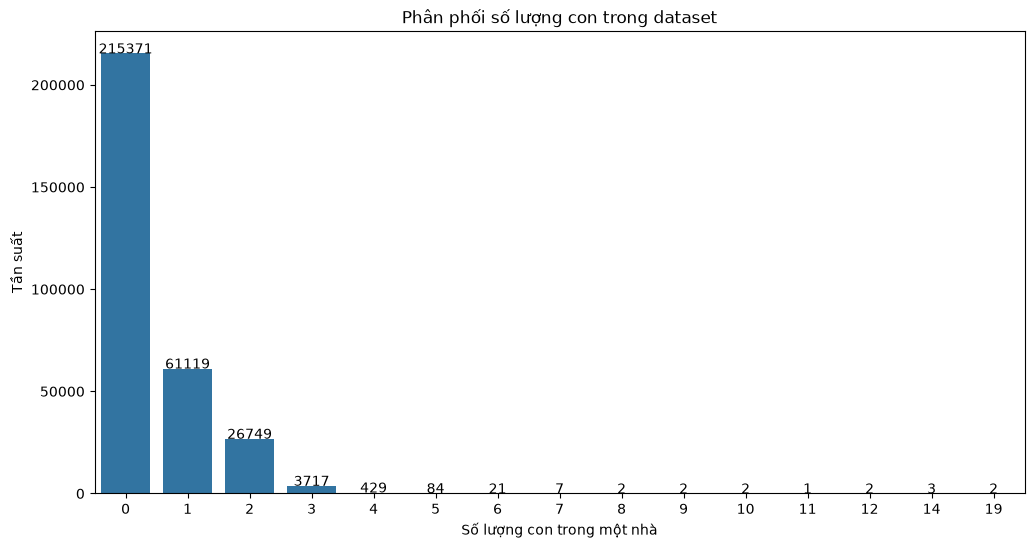

In [54]:
# Đếm số lượng từng giá trị unique
counts = df.value_counts().sort_index()

plt.figure(figsize=(12,6))
ax = sns.barplot(x=counts.index, y=counts.values)

plt.xlabel('Số lượng con trong một nhà')
plt.ylabel('Tần suất')
plt.title('Phân phối số lượng con trong dataset')

# Hiển thị số lượng trên đầu mỗi cột
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.show()

## So sánh cột CNT_CHILDREN và TARGET 

In [55]:
df = application_train[['CNT_CHILDREN','TARGET']]

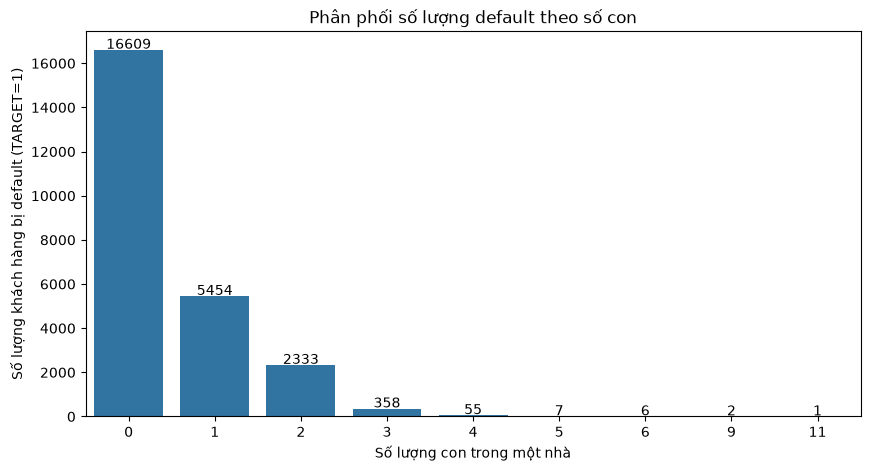

In [56]:
# Nhóm theo CNT_CHILDREN và đếm số lượng TARGET=1
counts = df[df['TARGET'] == 1]['CNT_CHILDREN'].value_counts().sort_index()

plt.figure(figsize=(10,5))
ax = sns.barplot(x=counts.index, y=counts.values)

plt.xlabel('Số lượng con trong một nhà')
plt.ylabel('Số lượng khách hàng bị default (TARGET=1)')
plt.title('Phân phối số lượng default theo số con')

# Hiển thị số lượng ngay trên đầu mỗi cột
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.show()


### Phần trăm những người ở từ 1-4 con, bị đánh taget là 1 

In [57]:
df = application_train[['CNT_CHILDREN','TARGET']]

In [58]:
application_train['FLAG_MOBIL'].isnull().sum()

np.int64(0)

In [59]:
for uni_value in df['CNT_CHILDREN'].unique():   
    df_unique_val = df[df['CNT_CHILDREN'] == uni_value]
    df_taget_1 = df[(df['CNT_CHILDREN'] == uni_value) & df['TARGET'] == 1]
    percent_df_val = (len(df_taget_1)/ len(df_unique_val))* 100
    print(f'Tỉ lệ không trả được nợ dựa trên số lượng con là {uni_value} :{percent_df_val:.2f}%')

Tỉ lệ không trả được nợ dựa trên số lượng con là 0 :7.71%
Tỉ lệ không trả được nợ dựa trên số lượng con là 1 :8.92%
Tỉ lệ không trả được nợ dựa trên số lượng con là 2 :8.72%
Tỉ lệ không trả được nợ dựa trên số lượng con là 3 :9.63%
Tỉ lệ không trả được nợ dựa trên số lượng con là 4 :12.82%
Tỉ lệ không trả được nợ dựa trên số lượng con là 7 :0.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 5 :8.33%
Tỉ lệ không trả được nợ dựa trên số lượng con là 6 :28.57%
Tỉ lệ không trả được nợ dựa trên số lượng con là 8 :0.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 9 :100.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 11 :100.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 12 :0.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 10 :0.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 19 :0.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 14 :0.00%


# Báo cáo phân tích đặc trưng: Số lượng con (`CNT_CHILDREN`)

## 1. Phân tích phân phối và giá trị ngoại lệ (Outliers)
Qua khảo sát biểu đồ phân phối của biến `CNT_CHILDREN`, chúng ta ghi nhận sự xuất hiện của các giá trị ngoại lệ (outliers) đối với những hộ gia đình có trên 5 người con.

- **Đánh giá thực tế:** Mặc dù đây là các trường hợp có khả năng xảy ra trong thực tế, nhưng tần suất xuất hiện rất thấp.
- **Ảnh hưởng đến mô hình:** Các giá trị cực đoan này có thể gây nhiễu, làm giảm độ chính xác và khả năng tổng quát hóa của mô hình dự đoán. Việc xử lý nhóm này là cần thiết để tập trung vào hành vi của đại đa số khách hàng.

## 2. Mối tương quan giữa số lượng con và khả năng vỡ nợ (`TARGET`)
Kết quả phân tích phân khúc (segmentation) cho thấy mối tương quan rõ rệt giữa quy mô gia đình và rủi ro tín dụng:

- **Xu hướng vay:** Nhóm khách hàng có **0 con** chiếm tỷ trọng lớn nhất, theo sau là nhóm có 1 và 2 con. Điều này phản ánh nhu cầu vay vốn cao ở nhóm khách hàng trẻ hoặc người có ít trách nhiệm nuôi dạy con cái hơn.
- **Rủi ro vỡ nợ:** Dữ liệu cho thấy sự chênh lệch rõ rệt về tỷ lệ vỡ nợ (`TARGET=1`):
    - Nhóm khách hàng có **0 con** có tỷ lệ vỡ nợ thấp nhất, đạt mức **7.71%**.
    - Tỷ lệ vỡ nợ có xu hướng **tăng dần** tương ứng với sự gia tăng số lượng con trong gia đình.
    - Tỷ lệ này đạt mức cao nhất ở nhóm khách hàng có từ 5 người con trở lên.

## 3. Kết luận và đề xuất xử lý
Từ các phân tích trên, có thể khẳng định: **Số lượng con cái tỷ lệ thuận với xác suất vỡ nợ của khách hàng.** ### Đề xuất hành động:
1. **Xử lý dữ liệu:** Áp dụng phương pháp gộp nhóm (binning) hoặc *Winsorization* cho các trường hợp có từ 5 người con trở lên để hạn chế nhiễu từ các giá trị ngoại lệ thay vì xóa bỏ hoàn toàn.
2. **Feature Engineering:** Tiếp tục sử dụng biến `CNT_CHILDREN` vì đây là biến số có khả năng dự báo rủi ro tốt.
3. **Phân tích bổ trợ:** Nên kết hợp thêm biến `NAME_FAMILY_STATUS` để hiểu rõ hơn về tình trạng hôn nhân và hoàn cảnh kinh tế, tránh kết luận vội vàng về trạng thái gia đình của khách hàng.

### Phân tích cột NAME_FAMILY_STATUS

In [60]:
df = application_train['NAME_FAMILY_STATUS']

In [61]:
df.describe()

count      307511
unique          6
top       Married
freq       196432
Name: NAME_FAMILY_STATUS, dtype: object

In [62]:
df.unique()

<StringArray>
['Single / not married',              'Married',       'Civil marriage',
                'Widow',            'Separated',              'Unknown']
Length: 6, dtype: str

### Ý nghĩa các giá trị trong cột:
- Single / not married: Người độc thân, chưa từng kết hôn.
- Married: Người đã kết hôn hợp pháp.
- Civil marriage: Kết hôn thực tế (sống chung như vợ chồng nhưng không đăng ký kết hôn chính thức).
- Widow: Người góa phụ 
- Separated: Người đã ly thân hoặc đã ly hôn.
- Unknown: Dữ liệu bị thiếu hoặc không được xác định.


In [63]:
df.isnull().sum()

np.int64(0)

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\455069695.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")


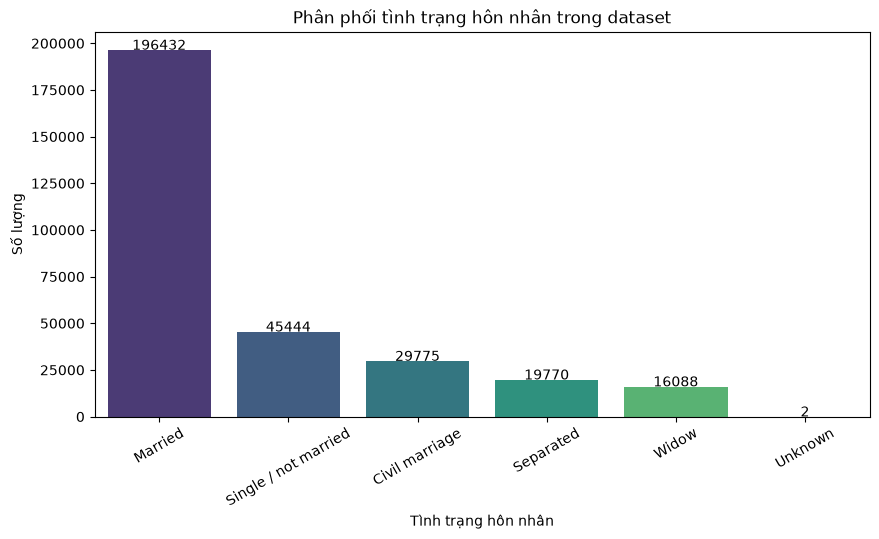

In [64]:
# Đếm số lượng từng giá trị unique
counts = df.value_counts()

plt.figure(figsize=(10,5))
ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")

plt.xlabel('Tình trạng hôn nhân')
plt.ylabel('Số lượng')
plt.title('Phân phối tình trạng hôn nhân trong dataset')

# Hiển thị số lượng trên đầu mỗi cột
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.xticks(rotation=30)  # xoay nhãn X cho dễ đọc
plt.show()

In [65]:
df = application_train[['NAME_FAMILY_STATUS','TARGET']]

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\331892272.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")


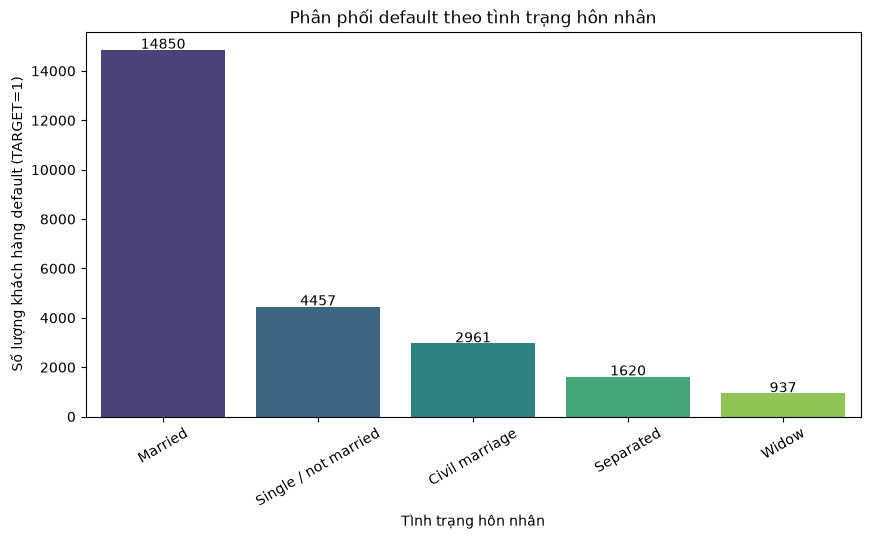

In [66]:
df_default = df[df['TARGET'] == 1]
counts = df_default['NAME_FAMILY_STATUS'].value_counts()

plt.figure(figsize=(10,5))
ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")

plt.xlabel('Tình trạng hôn nhân')
plt.ylabel('Số lượng khách hàng default (TARGET=1)')
plt.title('Phân phối default theo tình trạng hôn nhân')

# Hiển thị số lượng trên đầu mỗi cột
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.xticks(rotation=30)  # xoay nhãn X cho dễ đọc
plt.show()

In [67]:
for uni_value in df['NAME_FAMILY_STATUS'].unique():   
    df_unique_val = df[df['NAME_FAMILY_STATUS'] == uni_value]
    df_taget_1 = df[(df['NAME_FAMILY_STATUS'] == uni_value) & df['TARGET'] == 1]
    percent_df_val = (len(df_taget_1)/ len(df_unique_val))* 100
    print(f'Tỉ lệ không trả được nợ dựa trên số lượng con là {uni_value} :{percent_df_val:.2f}%')

Tỉ lệ không trả được nợ dựa trên số lượng con là Single / not married :9.81%
Tỉ lệ không trả được nợ dựa trên số lượng con là Married :7.56%
Tỉ lệ không trả được nợ dựa trên số lượng con là Civil marriage :9.94%
Tỉ lệ không trả được nợ dựa trên số lượng con là Widow :5.82%
Tỉ lệ không trả được nợ dựa trên số lượng con là Separated :8.19%
Tỉ lệ không trả được nợ dựa trên số lượng con là Unknown :0.00%


- Biểu đồ một thể hiện số lượng các tình trạng hôn nhân có trogn dữ liệu
    - Tình trạng hôn nhân chiếm tỉ trong cao nhất, có tính ảnh hưởng tới model cáo nhất nên cần xử lí tốt nhất
- Biểu đồ hai thể hiện số lượng các tình trạng hôn nhân bị target là 1 trong dữ liệu

### Phân tích cột DAYS_BIRTH

In [68]:
df = application_train[['DAYS_BIRTH','TARGET']]

In [69]:
df.head()

,DAYS_BIRTH,TARGET
0,-9461,1
1,-16765,0
2,-19046,0
3,-19005,0
4,-19932,0


In [70]:
df['DAYS_BIRTH'].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

In [71]:
df['DAYS_BIRTH'].isnull().sum()

np.int64(0)

In [72]:
df['DAYS_BIRTH'].unique()

array([ -9461, -16765, -19046, ...,  -7951,  -7857, -25061],
      shape=(17460,))

In [73]:
df['DAYS_BIRTH'] = abs(round(df['DAYS_BIRTH']/365))

In [74]:
df['DAYS_BIRTH'].describe()

count    307511.000000
mean         43.938646
std          11.964047
min          21.000000
25%          34.000000
50%          43.000000
75%          54.000000
max          69.000000
Name: DAYS_BIRTH, dtype: float64

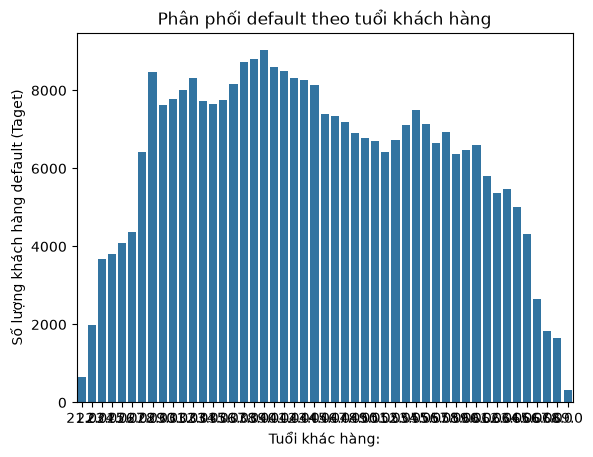

In [75]:
plt.Figure(figsize=(20,10))
sns.barplot(df['DAYS_BIRTH'].value_counts())
plt.xlabel("Tuổi khác hàng:")
plt.ylabel("Số lượng khách hàng default (Taget)")
plt.title('Phân phối default theo tuổi khách hàng')
# Hiển thị số lượng trên đầu mỗi cột
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=9)

plt.show()



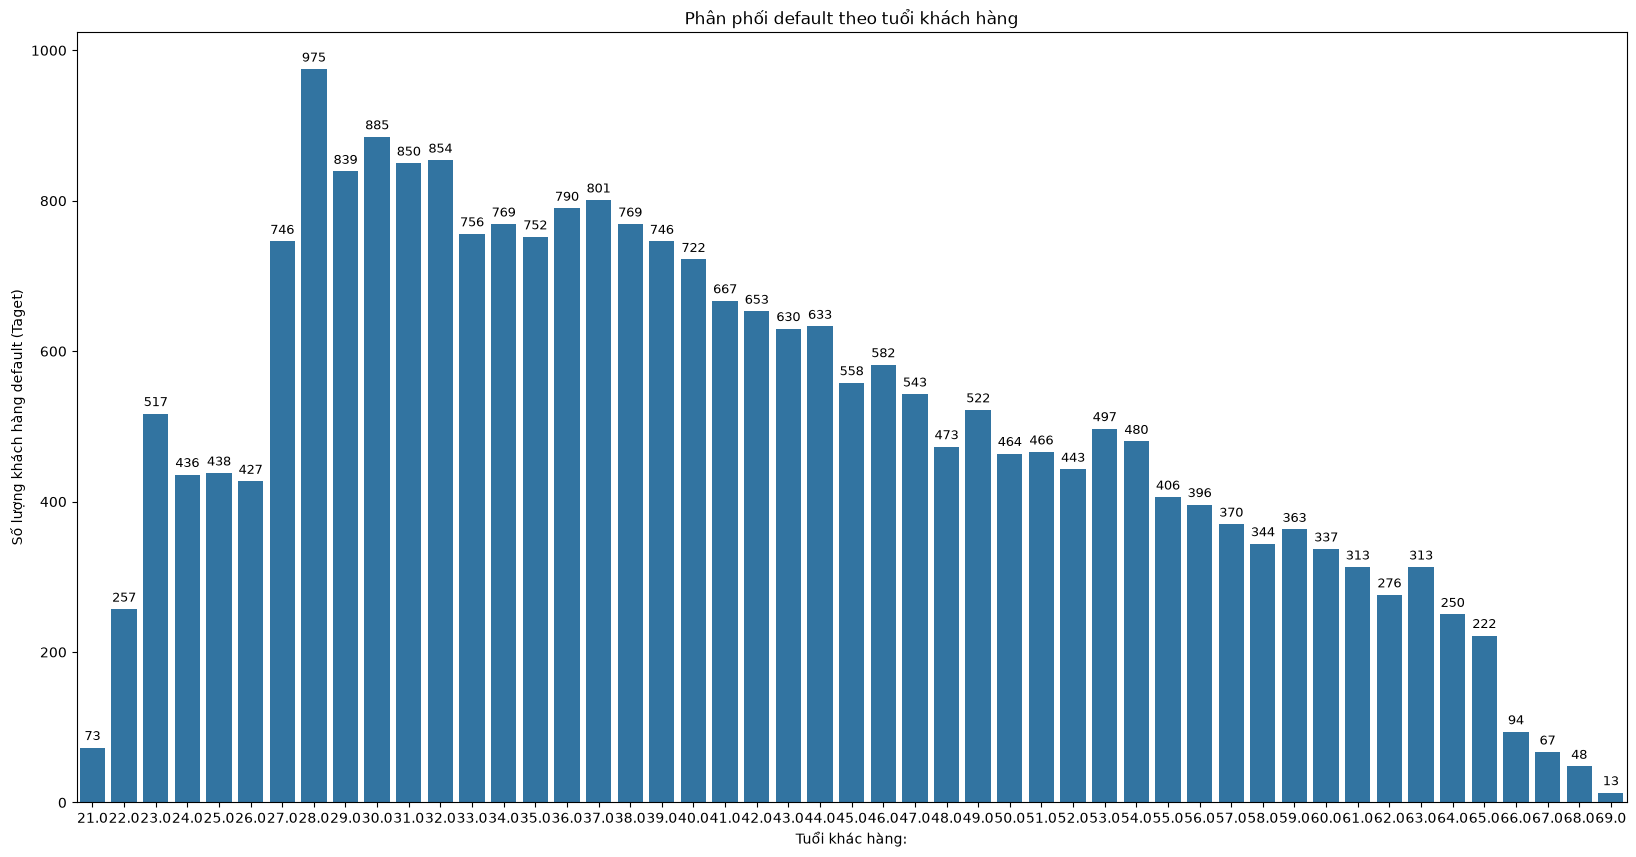

In [76]:
df_taget_1 = df[df['TARGET']==1]
counts = df_taget_1['DAYS_BIRTH'].value_counts().sort_index()

plt.figure(figsize=(20,10))
ax = sns.barplot(x=counts.index, y=counts.values)
plt.xlabel("Tuổi khác hàng:")
plt.ylabel("Số lượng khách hàng default (Taget)")
plt.title('Phân phối default theo tuổi khách hàng')
# Hiển thị số lượng trên đầu mỗi cột
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=9)

plt.show()

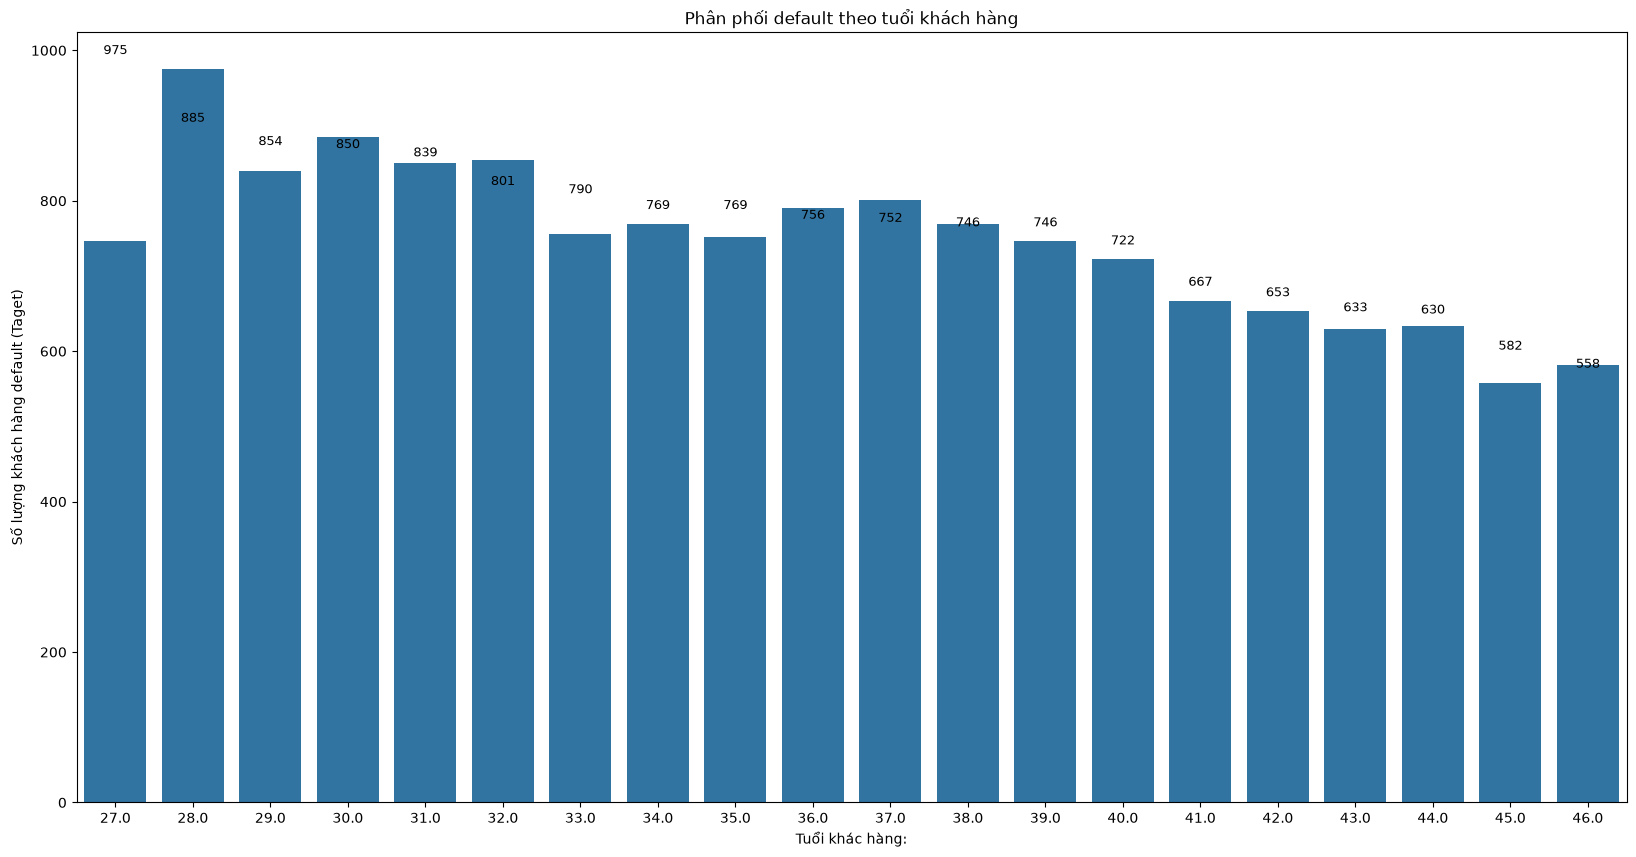

In [77]:
top20 = counts.nlargest(20)

plt.figure(figsize=(20,10))
ax = sns.barplot(x=top20.index, y=top20.values)
plt.xlabel("Tuổi khác hàng:")
plt.ylabel("Số lượng khách hàng default (Taget)")
plt.title('Phân phối default theo tuổi khách hàng')
# Hiển thị số lượng trên đầu mỗi cột
for i, v in enumerate(top20.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=9)

plt.show()

# Báo cáo phân tích mối tương quan: Độ tuổi (`DAYS_BIRTH`) và Rủi ro tín dụng (`TARGET`)

## 1. Xu hướng tổng quan
Dựa trên phân tích tỷ lệ vỡ nợ (default rate) theo độ tuổi, chúng ta ghi nhận sự biến động rõ rệt về khả năng trả nợ của khách hàng:

- **Giai đoạn 21 - 28 tuổi:** Tỷ lệ rủi ro có xu hướng tăng dần và đạt đỉnh tại ngưỡng 28 tuổi.
- **Giai đoạn 28 - 46 tuổi:** Tỷ lệ rủi ro ghi nhận xu hướng giảm dần, dù tốc độ giảm không đồng nhất qua từng mốc tuổi.

## 2. Phân tích nguyên nhân (Dựa trên dữ liệu)

### Nhóm 21 - 28 tuổi (Giai đoạn rủi ro cao)
- **Đặc điểm:** Sự gia tăng đột biến về rủi ro ở nhóm khách hàng trẻ.
- **Phân tích:** Điều này có thể xuất phát từ sự thiếu ổn định về thu nhập và kinh nghiệm quản lý tài chính cá nhân trong những năm đầu gia nhập thị trường lao động. Nhu cầu chi tiêu trong giai đoạn này thường có xu hướng vượt quá khả năng tài chính, dẫn đến áp lực nợ vay cao hơn.

### Nhóm trên 28 tuổi (Giai đoạn rủi ro giảm dần)
- **Đặc điểm:** Xu hướng giảm tỷ lệ vỡ nợ rõ rệt.
- **Phân tích:** Sự ổn định hơn trong năng lực tài chính ở độ tuổi này là yếu tố then chốt. Việc thăng tiến trong sự nghiệp, ổn định về gia đình (kết hợp dữ liệu từ `NAME_FAMILY_STATUS`) và sự trưởng thành trong tư duy quản lý tài chính giúp khách hàng thực hiện nghĩa vụ trả nợ tốt hơn.

## 3. Nhận định kỹ thuật
- **Chuẩn hóa dữ liệu:** Để đảm bảo tính khách quan, biểu đồ đã được chuẩn hóa theo **tỷ lệ (%) trên tổng số người vay** ở mỗi độ tuổi, loại bỏ sai lệch do sự chênh lệch quy mô mẫu giữa các nhóm tuổi.
- **Phân tích đa biến:** Độ tuổi là một chỉ số dự báo mạnh, tuy nhiên cần phân tích kết hợp với các biến `NAME_INCOME_TYPE` và `NAME_EDUCATION_TYPE` để đối chiếu và khẳng định các giả thuyết về áp lực tài chính sớm.

## 4. Kết luận
Độ tuổi là một đặc trưng (feature) có giá trị dự báo cao. Các khách hàng trong phân khúc 21 - 28 tuổi nên được áp dụng chính sách xét duyệt tín dụng chặt chẽ hơn. Ngược lại, nhóm khách hàng trên 28 tuổi có xu hướng trở thành nhóm khách hàng tiềm năng an toàn hơn cho danh mục cho vay của tổ chức.

## Phân tích NAME_EDUCATION_TYP, NAME_INCOME_TYPE và OCCUPATION_TYPE

In [78]:
df = application_train[['NAME_EDUCATION_TYPE','OCCUPATION_TYPE','ORGANIZATION_TYPE',"TARGET"]]


In [79]:
df['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [80]:
application_train['NAME_EDUCATION_TYPE'].isnull().sum()

np.int64(0)

In [81]:
df['NAME_EDUCATION_TYPE'].describe()

count                            307511
unique                                5
top       Secondary / secondary special
freq                             218391
Name: NAME_EDUCATION_TYPE, dtype: object

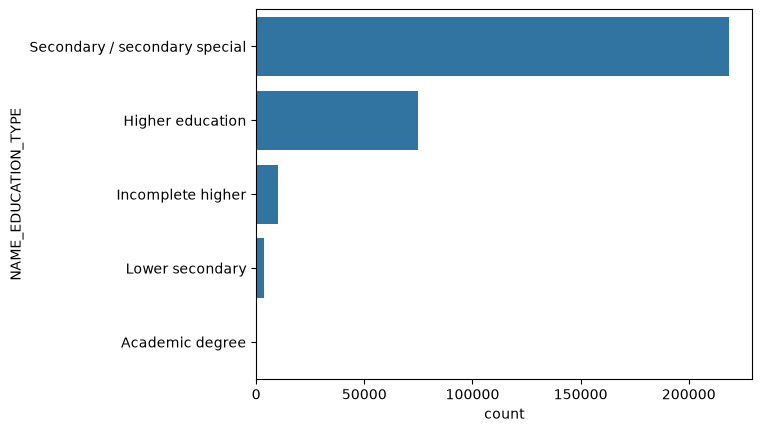

In [82]:
plt.Figure(figsize=(10,8))
sns.barplot(df['NAME_EDUCATION_TYPE'].value_counts(),orient='h')
plt.show()

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\1073462207.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")


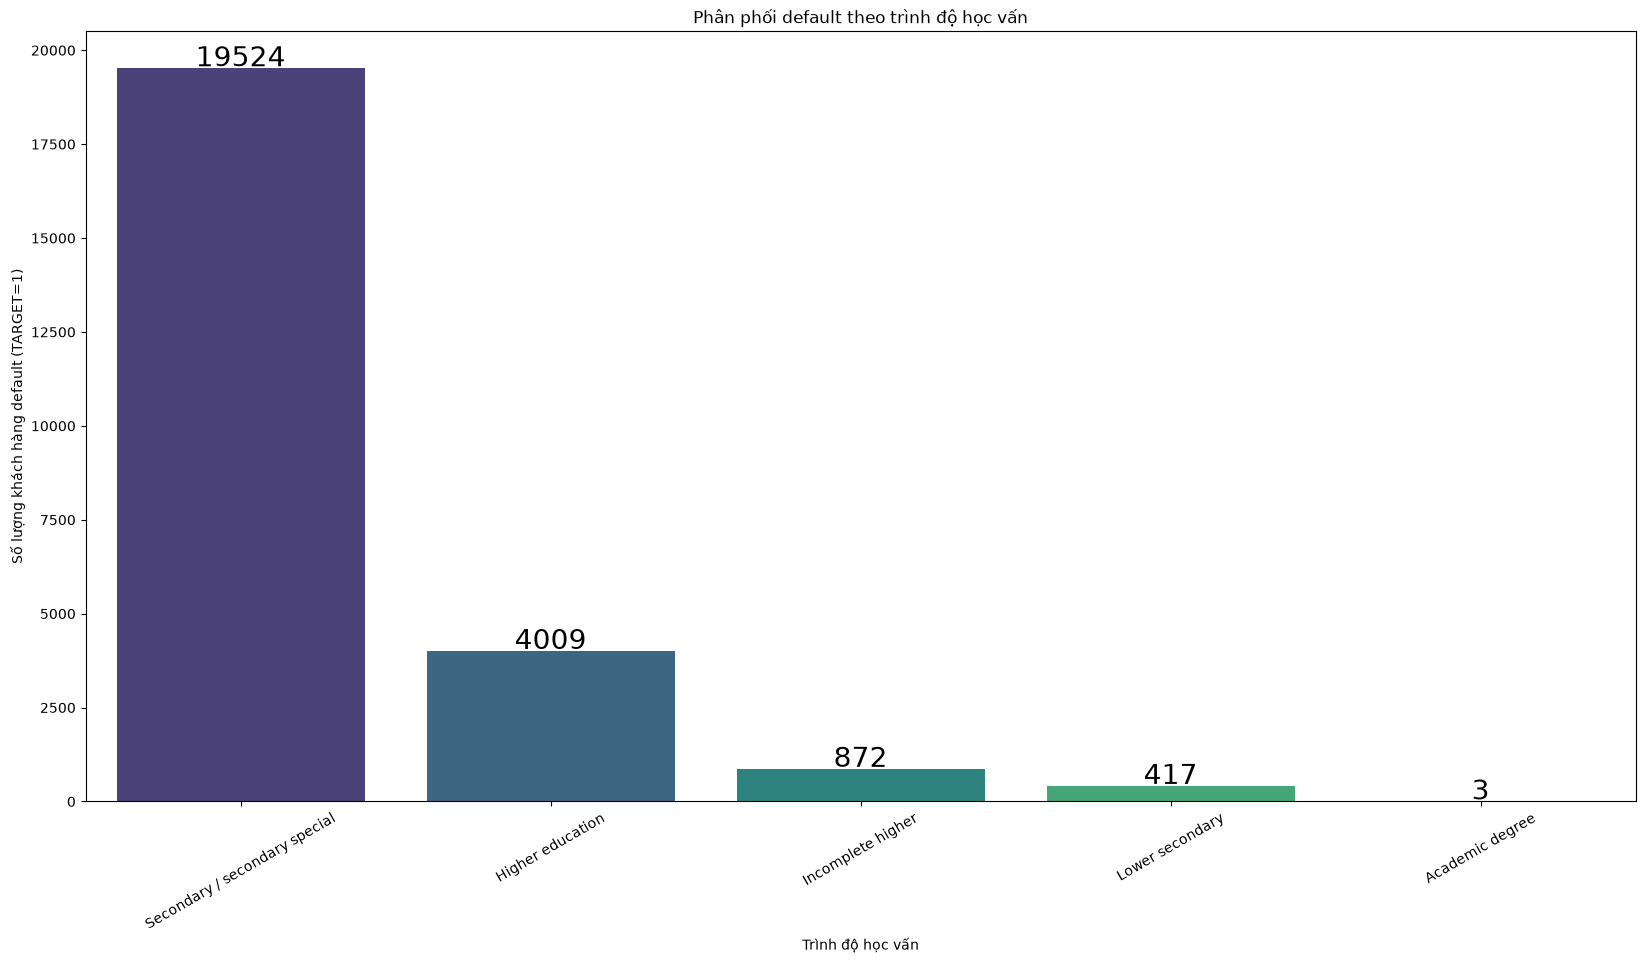

In [83]:
df_target_1 = df[df['TARGET']==1]

# Đếm số lượng default theo trình độ học vấn
counts = df_target_1['NAME_EDUCATION_TYPE'].value_counts()

plt.figure(figsize=(20,10))
ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")

plt.xlabel("Trình độ học vấn")
plt.ylabel("Số lượng khách hàng default (TARGET=1)")
plt.title("Phân phối default theo trình độ học vấn")

# Hiển thị số lượng trên đầu mỗi cột
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=20)

plt.xticks(rotation=30)  # xoay nhãn X cho dễ đọc
plt.show()


In [84]:
counts = df_target_1['NAME_EDUCATION_TYPE'].value_counts()
counts

NAME_EDUCATION_TYPE
Secondary / secondary special    19524
Higher education                  4009
Incomplete higher                  872
Lower secondary                    417
Academic degree                      3
Name: count, dtype: int64

In [85]:
for uni_value in df['NAME_EDUCATION_TYPE'].unique():
    val_target_1 = len(df_target_1[df_target_1['NAME_EDUCATION_TYPE']== uni_value])
    val = len(df[df['NAME_EDUCATION_TYPE'] == uni_value])
    precent = round((val_target_1/val)*100,2)
    print(f"Phần trăm học vấn {uni_value} : {precent}%")

Phần trăm học vấn Secondary / secondary special : 8.94%
Phần trăm học vấn Higher education : 5.36%
Phần trăm học vấn Incomplete higher : 8.48%
Phần trăm học vấn Lower secondary : 10.93%
Phần trăm học vấn Academic degree : 1.83%


# Báo cáo phân tích: Trình độ học vấn và Rủi ro tín dụng (`NAME_EDUCATION_TYPE`)

## 1. Tổng quan dữ liệu
Việc phân tích sự phân bổ của khách hàng theo trình độ học vấn cho thấy sự chênh lệch lớn về quy mô mẫu. Nhóm khách hàng có trình độ "Secondary / secondary special" chiếm ưu thế tuyệt đối trong tập dữ liệu, trong khi nhóm "Academic degree" có quy mô rất nhỏ.

## 2. Phân tích tỷ lệ vỡ nợ (`TARGET = 1`)
Dựa trên tỷ lệ vỡ nợ tính toán được trên từng nhóm học vấn, ta ghi nhận kết quả như sau:

| Trình độ học vấn | Tổng số khách hàng | Khách hàng vỡ nợ (Target=1) | Tỷ lệ vỡ nợ (%) |
| :--- | :--- | :--- | :--- |
| **Lower secondary** | 3,816 | 417 | **10.93%** |
| **Secondary / secondary special** | 218,391 | 19,524 | **8.94%** |
| **Incomplete higher** | 10,277 | 872 | **8.48%** |
| **Higher education** | 74,863 | 4,009 | **5.36%** |
| **Academic degree** | 164 | 3 | **1.83%** |

## 3. Nhận định chuyên sâu
- **Tương quan nghịch giữa học vấn và rủi ro:** Dữ liệu cho thấy một xu hướng rõ ràng: Trình độ học vấn càng cao, tỷ lệ vỡ nợ có xu hướng càng thấp. Nhóm "Lower secondary" (học vấn thấp nhất) có tỷ lệ rủi ro cao nhất (10.93%), trong khi nhóm "Higher education" và "Academic degree" có tỷ lệ rủi ro thấp đáng kể.
- **Nhóm tiềm năng:** Khách hàng có trình độ từ Đại học trở lên ("Higher education") là nhóm đối tượng an toàn nhất cho ngân hàng với tỷ lệ vỡ nợ chỉ 5.36%.
- **Lưu ý về độ tin cậy:** Nhóm "Academic degree" có tỷ lệ vỡ nợ thấp nhất (1.83%) nhưng quy mô mẫu quá nhỏ (chỉ 164 người). Cần thận trọng khi đưa ra kết luận mang tính đại diện cho nhóm này vì khả năng sai số thống kê cao.

## 4. Kết luận và đề xuất
- **Phân loại tín dụng:** Trình độ học vấn là một biến số mạnh để đánh giá năng lực trả nợ. Ngân hàng có thể cân nhắc các chính sách ưu đãi hoặc nới lỏng hơn cho nhóm khách hàng có trình độ học vấn cao.
- **Chiến lược kiểm soát:** Nhóm khách hàng có trình độ "Secondary / secondary special" và "Lower secondary" nên là đối tượng cần được thẩm định hồ sơ chặt chẽ hơn do tỷ lệ rủi ro vượt ngưỡng 8%.

In [86]:
df['OCCUPATION_TYPE'].describe()

count       211120
unique          18
top       Laborers
freq         55186
Name: OCCUPATION_TYPE, dtype: object

In [87]:
print(f'% giá trị nah có trong dữ liệu OCCUPATION_TYPE : {(df['OCCUPATION_TYPE'].isnull().sum()/len(df))*100:.2f}%')

% giá trị nah có trong dữ liệu OCCUPATION_TYPE : 31.35%


In [88]:
df['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

- Laborers -> Lao động phổ thông, công nhân sản xuất, làm việc tay chân.
- Sales staff -> Nhân viên bán hàng, kinh doanh.
- Core staff -> Nhân viên nòng cốt trong công ty (hành chính, vận hành).
- Managers -> Quản lý, lãnh đạo cấp trung hoặc cao.
- Drivers -> Tài xế, lái xe.
- High skill tech staff -> Nhân viên kỹ thuật có tay nghề cao.
- Accountants -> Kế toán.
- Medicine staff -> Nhân viên y tế, bác sĩ, điều dưỡng.
- Security staff -> Nhân viên bảo vệ.
- Cooking staff -> Đầu bếp, nhân viên bếp.
- Cleaning staff -> Nhân viên vệ sinh.
- Private service staff -> Người làm dịch vụ cá nhân (giúp việc, chăm sóc).
- Low-skill Laborers -> Lao động phổ thông có kỹ năng thấp hơn nhóm “Laborers”.
- Waiters/barmen staff -> Nhân viên phục vụ bàn, pha chế.
- Secretaries -> Thư ký.
- Realty agents -> Nhân viên môi giới bất động sản.
- HR staff -> Nhân viên nhân sự.
- IT staff -> Nhân viên công nghệ thông tin.

In [89]:
def calculate_percent(raw_data, data_want_check,col):
    for uni_value in raw_data[col].dropna().unique():
        val_target_1 = len(data_want_check[data_want_check[col]== uni_value])
        val = len(raw_data[raw_data[col] == uni_value])
        precent = round((val_target_1/val)*100,2)
        print(f"Phần trăm {uni_value} : {precent}%")

In [90]:
def draw_Frequency_values(data: pd.Series, title: str = None, orient: bool = True):
    plt.figure(figsize=(10,8))
    counts = data.value_counts()

    if orient:  # biểu đồ ngang
        sns.barplot(x=counts.values, y=counts.index, orient='h', palette="viridis")
        plt.xlabel("Tần suất")
        plt.ylabel("Giá trị")
    else:       # biểu đồ dọc
        sns.barplot(x=counts.index, y=counts.values, palette="viridis")
        plt.xlabel("Giá trị")
        plt.ylabel("Tần suất")

    if title:
        plt.title(title)
    plt.show()


In [91]:
def compare_with_target(data: pd.Series, title: str = None, xlabel:str = None,
                        ylabel:str = None):
    plt.figure(figsize=(20,10))
    ax = sns.barplot(x=data.index, y=data.values, palette="viridis")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    # Hiển thị số lượng trên đầu mỗi cột
    for i, v in enumerate(data.values):
        ax.text(i, v + 50, str(v), ha='center', fontsize=20)

    plt.xticks(rotation=30)  # xoay nhãn X cho dễ đọc
    plt.show()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64


C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\4270974960.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


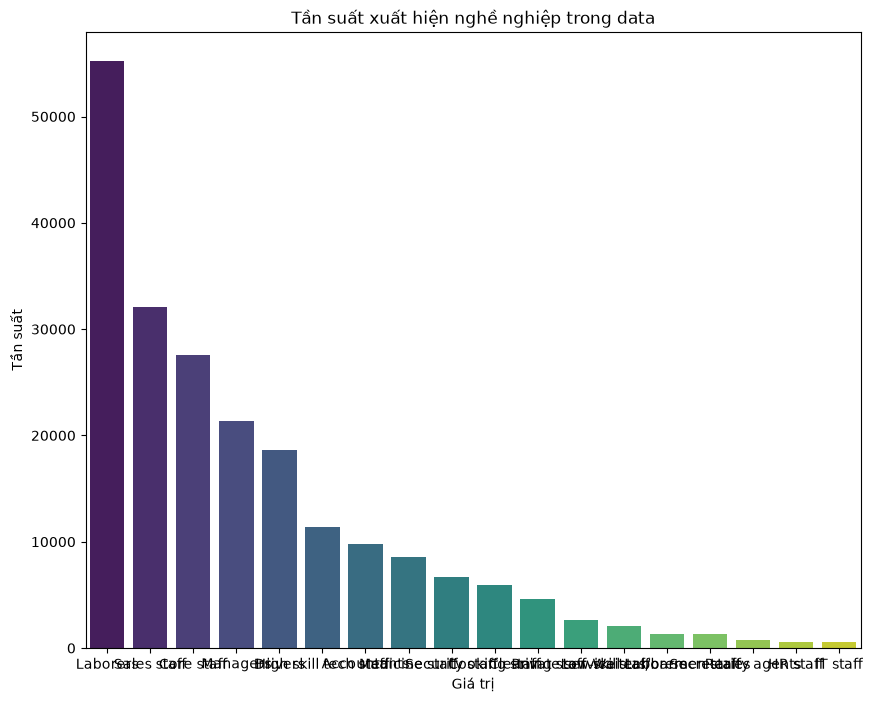

In [92]:
print(df['OCCUPATION_TYPE'].value_counts())
draw_Frequency_values(data=df['OCCUPATION_TYPE'],title='Tần suất xuất hiện nghề nghiệp trong data',orient=False)

OCCUPATION_TYPE
Laborers                 5838
Sales staff              3092
Drivers                  2107
Core staff               1738
Managers                 1328
Security staff            722
High skill tech staff     701
Cooking staff             621
Medicine staff            572
Accountants               474
Cleaning staff            447
Low-skill Laborers        359
Private service staff     175
Waiters/barmen staff      152
Secretaries                92
Realty agents              59
HR staff                   36
IT staff                   34
Name: count, dtype: int64


C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\1005847692.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=data.index, y=data.values, palette="viridis")


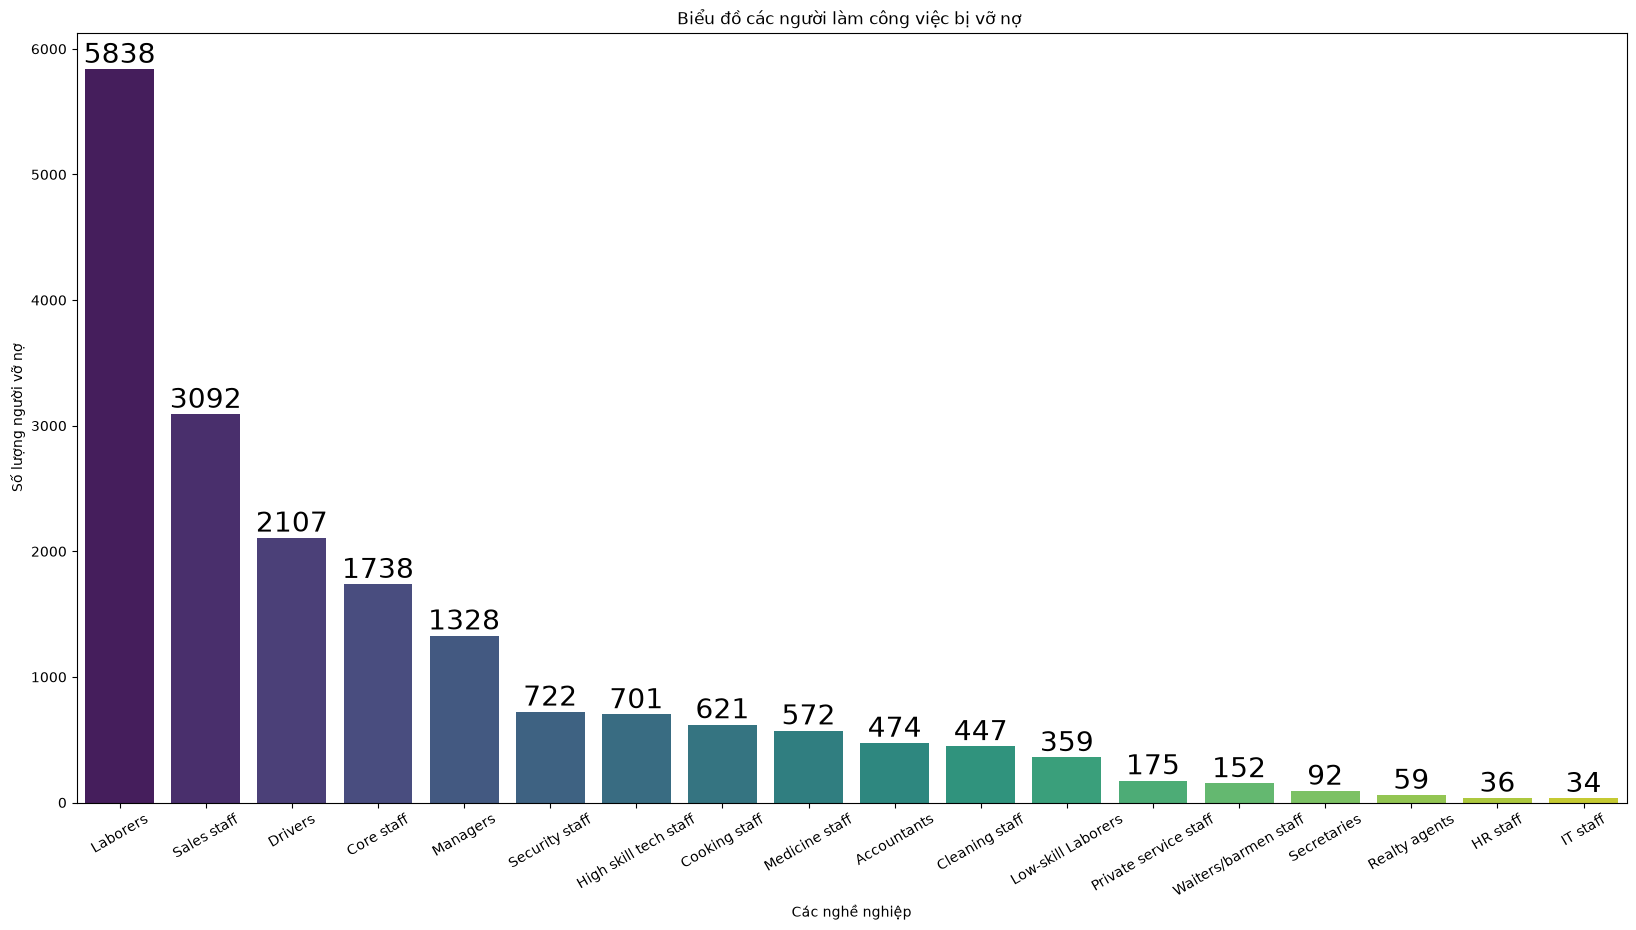

In [93]:
df_target_1 = df[df['TARGET']==1]
counts = df_target_1['OCCUPATION_TYPE'].value_counts()
print(counts)
compare_with_target(data=counts, title ='Biểu đồ các người làm công việc bị vỡ nợ ',
                    xlabel='Các nghề nghiệp',ylabel='Số lượng người vỡ nợ')

In [94]:
calculate_percent(raw_data=df,data_want_check=df_target_1,col='OCCUPATION_TYPE')

Phần trăm Laborers : 10.58%
Phần trăm Core staff : 6.3%
Phần trăm Accountants : 4.83%
Phần trăm Managers : 6.21%
Phần trăm Drivers : 11.33%
Phần trăm Sales staff : 9.63%
Phần trăm Cleaning staff : 9.61%
Phần trăm Cooking staff : 10.44%
Phần trăm Private service staff : 6.6%
Phần trăm Medicine staff : 6.7%
Phần trăm Security staff : 10.74%
Phần trăm High skill tech staff : 6.16%
Phần trăm Waiters/barmen staff : 11.28%
Phần trăm Low-skill Laborers : 17.15%
Phần trăm Realty agents : 7.86%
Phần trăm Secretaries : 7.05%
Phần trăm IT staff : 6.46%
Phần trăm HR staff : 6.39%


# Báo cáo phân tích: Nghề nghiệp và Rủi ro tín dụng (`OCCUPATION_TYPE`)

## 1. Bảng thống kê rủi ro theo nghề nghiệp
Dựa trên tỷ lệ vỡ nợ (Target=1), danh sách các nghề nghiệp được sắp xếp theo mức độ rủi ro từ cao đến thấp:

| Nghề nghiệp | Tỷ lệ vỡ nợ (%) |
| :--- | :--- |
| **Low-skill Laborers** | **17.15%** |
| **Drivers** | **11.33%** |
| **Waiters/barmen staff** | **11.28%** |
| **Security staff** | **10.74%** |
| **Laborers** | **10.58%** |
| **Cooking staff** | **10.44%** |
| **Sales staff** | **9.63%** |
| **Cleaning staff** | **9.61%** |
| **Realty agents** | **7.86%** |
| **Secretaries** | **7.05%** |
| **Medicine staff** | **6.70%** |
| **Private service staff** | **6.60%** |
| **HR staff** | **6.39%** |
| **Core staff** | **6.30%** |
| **Managers** | **6.21%** |
| **High skill tech staff** | **6.16%** |
| **IT staff** | **6.46%** |
| **Accountants** | **4.83%** |

## 2. Phân tích các yếu tố dẫn đến tỷ lệ rủi ro
Dữ liệu cho thấy sự phân hóa rõ rệt giữa các nhóm nghề nghiệp:

### Nhóm rủi ro cao (Tỷ lệ > 10%)
- **Đặc điểm:** Các nghề như *Low-skill Laborers, Drivers, Waiters, Security*.
- **Lý do khả dĩ:**
    - **Tính chất thu nhập:** Thu nhập thường không cố định hoặc theo giờ/ca.
    - **Tính bền vững:** Các ngành nghề này thường có mức độ biến động nhân sự cao và dễ bị ảnh hưởng bởi biến động thị trường lao động.
    - **Đặc thù công việc:** Mức lương cơ bản thấp cộng với thiếu các phúc lợi tài chính dài hạn tạo áp lực lớn khi xảy ra tình huống chi tiêu khẩn cấp.

### Nhóm rủi ro thấp (Tỷ lệ < 6%)
- **Đặc điểm:** Các nghề như *Accountants, Managers, High skill tech, IT*.
- **Lý do khả dĩ:**
    - **Tính ổn định:** Đây là các vị trí đòi hỏi trình độ chuyên môn cao, thường đi kèm với hợp đồng lao động dài hạn và chế độ đãi ngộ ổn định.
    - **Khả năng quản lý:** Những người làm việc trong các ngành tài chính, quản lý thường có tư duy và kỹ năng quản lý tài chính cá nhân tốt hơn, giúp họ kiểm soát nợ vay hiệu quả hơn.

## 3. Kết luận
Nghề nghiệp là một biến số dự báo cực kỳ mạnh mẽ. 
- Ngân hàng nên áp dụng **mô hình thẩm định phân tầng**: Nhóm rủi ro cao cần yêu cầu thêm các tài sản đảm bảo hoặc lịch sử tín dụng minh bạch hơn.
- **Lưu ý về dữ liệu:** Nhóm *Low-skill Laborers* dù có tỷ lệ vỡ nợ cao nhất (17.15%) nhưng quy mô mẫu (2,093) nhỏ hơn rất nhiều so với *Laborers* (55,186). Sự khác biệt về quy mô mẫu cần được cân nhắc kỹ để tránh sai lệch khi huấn luyện mô hình dự đoán.

In [95]:
df['ORGANIZATION_TYPE'].describe()

count                     307511
unique                        58
top       Business Entity Type 3
freq                       67992
Name: ORGANIZATION_TYPE, dtype: object

In [96]:
df['ORGANIZATION_TYPE'].isnull().sum()

np.int64(0)

In [97]:
df['ORGANIZATION_TYPE'].unique()

<StringArray>
['Business Entity Type 3',                 'School',             'Government',
               'Religion',                  'Other',                    'XNA',
            'Electricity',               'Medicine', 'Business Entity Type 2',
          'Self-employed',      'Transport: type 2',           'Construction',
                'Housing',           'Kindergarten',          'Trade: type 7',
      'Industry: type 11',               'Military',               'Services',
    'Security Ministries',      'Transport: type 4',       'Industry: type 1',
              'Emergency',               'Security',          'Trade: type 2',
             'University',      'Transport: type 3',                 'Police',
 'Business Entity Type 1',                 'Postal',       'Industry: type 4',
            'Agriculture',             'Restaurant',                'Culture',
                  'Hotel',       'Industry: type 7',          'Trade: type 3',
       'Industry: type 3',            

# Phân tích & Xử lý: `ORGANIZATION_TYPE`

## 1. Phân loại nhóm tổ chức
Do có 58 loại hình, cần gộp nhóm để giảm nhiễu cho mô hình:

- **Khối Công chức/Nhà nước**: `Government`, `Military`, `Police`, `Security Ministries` (Độ ổn định cao).
- **Khối Tài chính/Chuyên gia**: `Bank`, `Insurance`, `Medicine`, `School`, `University` (Thu nhập ổn định).
- **Khối Kinh doanh/Thương mại**: `Business Entity Type 1, 2, 3`, `Trade`, `Services` (Phụ thuộc thị trường).
- **Khối Tự doanh/Khác**: `Self-employed`, `Realtor`, `Construction` (Thu nhập biến động).
- **Nhóm Đặc biệt**: `XNA` (Khách hàng không làm công ăn lương, thường là hưu trí/nội trợ).

## 2. Ý nghĩa phân tích
- **Độ ổn định**: Các tổ chức Nhà nước/Giáo dục/Y tế có rủi ro vỡ nợ thấp hơn do tính bảo mật công việc cao.
- **Rủi ro thị trường**: Các nhóm *Self-employed* hoặc *Construction* dễ chịu tác động từ suy thoái kinh tế, dẫn đến rủi ro vỡ nợ cao hơn.
- **Biến `XNA`**: Đây không phải dữ liệu rác. Nhóm này đại diện cho phân khúc khách hàng không có thu nhập từ lương, cần phân tích riêng biệt để đánh giá rủi ro.

## 3. Đề xuất xử lý
1. **Gộp nhóm (Binning)**: Chuyển 58 giá trị về 6-8 nhóm chính dựa trên tính chất ổn định tài chính.
2. **Encoding**: Sử dụng *Target Encoding* (gán giá trị dựa trên tỷ lệ vỡ nợ trung bình của nhóm đó) để giữ lại thông tin rủi ro thay vì dùng *One-Hot Encoding* làm phình to dữ liệu.
3. **Ưu tiên**: Coi `XNA` là một category độc lập, không bỏ qua vì đây là nhóm khách hàng có hành vi vay khác biệt.

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\4270974960.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, orient='h', palette="viridis")


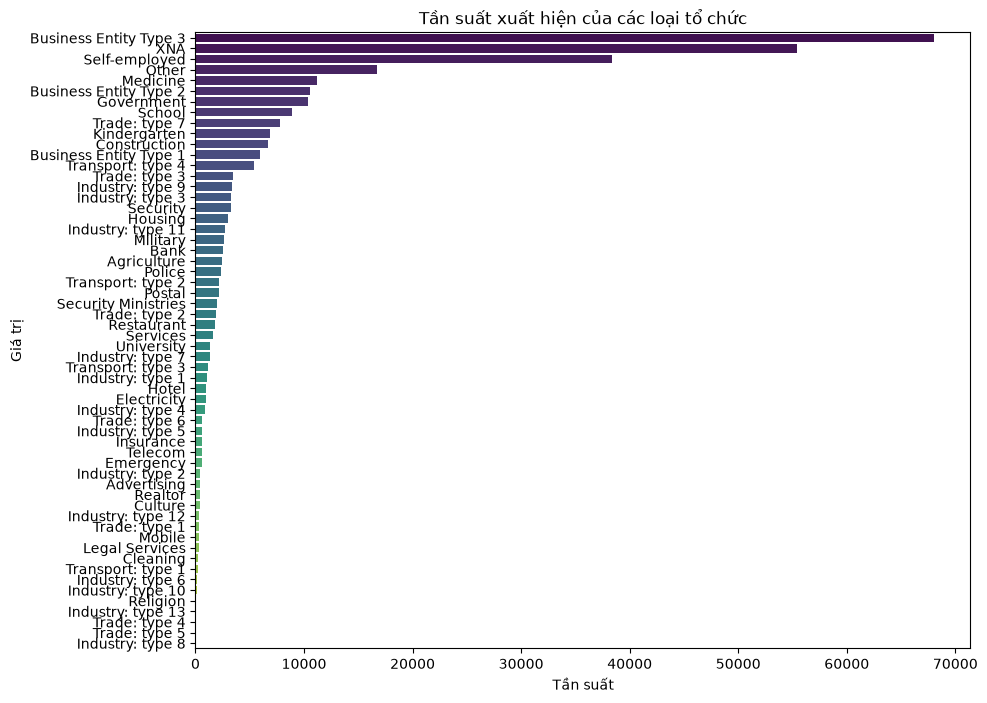

In [98]:
print(df['ORGANIZATION_TYPE'].value_counts())
draw_Frequency_values(data=df['ORGANIZATION_TYPE'],title='Tần suất xuất hiện của các loại tổ chức')

ORGANIZATION_TYPE
Business Entity Type 3    6323
Self-employed             3908
XNA                       2990
Other                     1275
Business Entity Type 2     900
Construction               785
Trade: type 7              740
Medicine                   737
Government                 726
School                     526
Transport: type 4          501
Business Entity Type 1     487
Kindergarten               484
Trade: type 3              361
Industry: type 3           348
Security                   324
Agriculture                257
Housing                    235
Industry: type 11          234
Industry: type 9           225
Restaurant                 212
Transport: type 3          187
Postal                     182
Transport: type 2          172
Military                   135
Trade: type 2              133
Bank                       130
Police                     117
Industry: type 1           115
Industry: type 7           105
Services                   104
Security Ministries  

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\1005847692.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=data.index, y=data.values, palette="viridis")


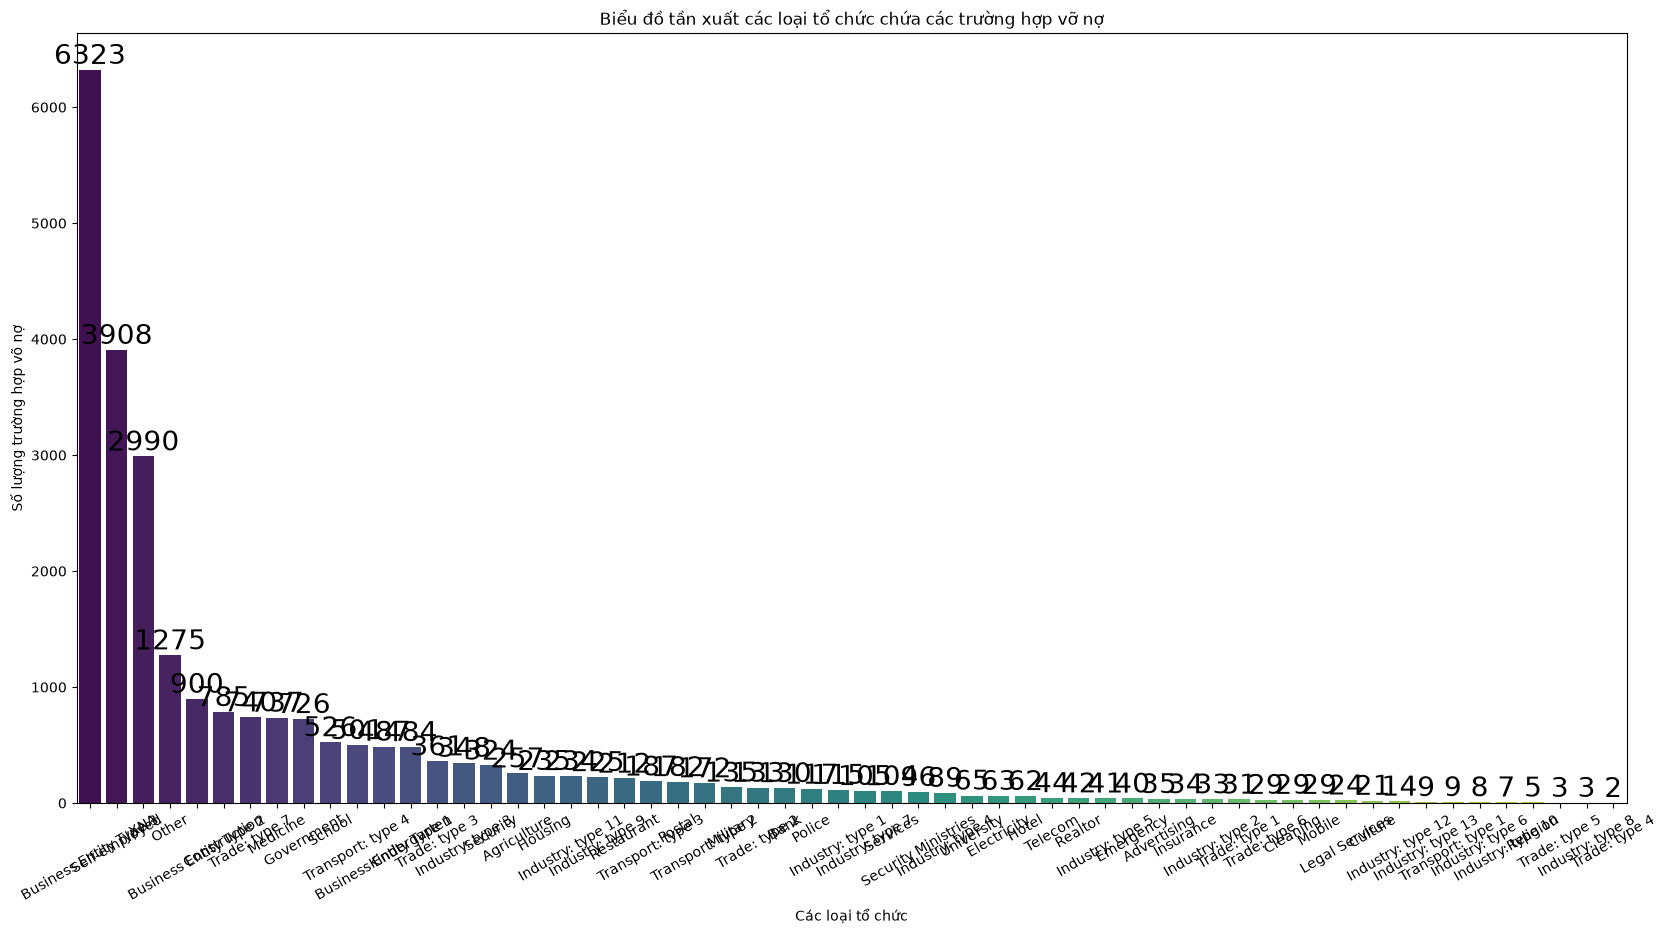

In [99]:
df_target_1 = df[df['TARGET']==1]
counts = df_target_1['ORGANIZATION_TYPE'].value_counts()
print(counts)
compare_with_target(data=counts,title='Biểu đồ tần xuất các loại tổ chức chứa các trường hợp vỡ nợ',
                    xlabel= 'Các loại tổ chức', ylabel= 'Số lượng trường hợp võ nợ')

In [100]:
calculate_percent(raw_data=df, data_want_check=df_target_1,col='ORGANIZATION_TYPE')

Phần trăm Business Entity Type 3 : 9.3%
Phần trăm School : 5.91%
Phần trăm Government : 6.98%
Phần trăm Religion : 5.88%
Phần trăm Other : 7.64%
Phần trăm XNA : 5.4%
Phần trăm Electricity : 6.63%
Phần trăm Medicine : 6.58%
Phần trăm Business Entity Type 2 : 8.53%
Phần trăm Self-employed : 10.17%
Phần trăm Transport: type 2 : 7.8%
Phần trăm Construction : 11.68%
Phần trăm Housing : 7.94%
Phần trăm Kindergarten : 7.03%
Phần trăm Trade: type 7 : 9.45%
Phần trăm Industry: type 11 : 8.65%
Phần trăm Military : 5.13%
Phần trăm Services : 6.6%
Phần trăm Security Ministries : 4.86%
Phần trăm Transport: type 4 : 9.28%
Phần trăm Industry: type 1 : 11.07%
Phần trăm Emergency : 7.14%
Phần trăm Security : 9.98%
Phần trăm Trade: type 2 : 7.0%
Phần trăm University : 4.9%
Phần trăm Transport: type 3 : 15.75%
Phần trăm Police : 5.0%
Phần trăm Business Entity Type 1 : 8.14%
Phần trăm Postal : 8.44%
Phần trăm Industry: type 4 : 10.15%
Phần trăm Agriculture : 10.47%
Phần trăm Restaurant : 11.71%
Phần trăm 

## Phân tích nhóm dữ liệu tình trạng tài chính (Khả năng chi trả)
đây là dữ liệu yêu cầu phải phân tích kĩ nhất vì nó có ảnh hưởng lớn với model dự đoán của AI

In [101]:
df = application_train[['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','NAME_HOUSING_TYPE','FLAG_OWN_REALTY','TARGET']]

In [102]:
check_missing_values(df)

Kiểm tra giá trị bị thiếu trong dataframe:
Cột AMT_ANNUITY có 12 missing values và chiếm 0.00%
Cột AMT_INCOME_TOTAL có 0 missing values và chiếm 0.00%
Cột AMT_CREDIT có 0 missing values và chiếm 0.00%
Cột NAME_HOUSING_TYPE có 0 missing values và chiếm 0.00%
Cột FLAG_OWN_REALTY có 0 missing values và chiếm 0.00%
Cột TARGET có 0 missing values và chiếm 0.00%


In [103]:
check_unique_values(df)

Kiểm tra giá trị duy nhất trong dataframe:
Cột AMT_INCOME_TOTAL có 2548 giá trị duy nhất.
Cột AMT_CREDIT có 5603 giá trị duy nhất.
Cột AMT_ANNUITY có 13672 giá trị duy nhất.
Cột NAME_HOUSING_TYPE có 6 giá trị duy nhất.
Cột FLAG_OWN_REALTY có 2 giá trị duy nhất.
Cột TARGET có 2 giá trị duy nhất.


In [104]:
for col in df.columns:
    print(df[col].unique())

[202500.  270000.   67500.  ...  96768.  546250.5 113062.5]
[ 406597.5 1293502.5  135000.  ...  181989.   743863.5 1391130. ]
[24700.5 35698.5  6750.  ... 71986.5 58770.  77809.5]
<StringArray>
[  'House / apartment',    'Rented apartment',        'With parents',
 'Municipal apartment',    'Office apartment',     'Co-op apartment']
Length: 6, dtype: str
<StringArray>
['Y', 'N']
Length: 2, dtype: str
[1 0]


In [105]:
for col in df.columns:
    print('-'*70)
    print(df[col].describe())

----------------------------------------------------------------------
count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64
----------------------------------------------------------------------
count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64
----------------------------------------------------------------------
count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64
----------------------------------------------------------------------
count                307511
unique                    6
top       House / 

Kiểm tra mức độ lệch của mean và median

In [106]:
cols = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY']
for col in cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    variation = round(abs(mean_val - median_val),3)
    percent_variati_mean = round((variation/median_val)*100,2)
    percent_variati_median = round((variation/mean_val)*100,2)
    print(f'Độ chênh lệch của mean và median{variation}')
    print(f'Phân trăm mean chênh lệch với median {percent_variati_mean}%')
    print(f'Phân trăm median chênh lệch với mean {percent_variati_median}%')
    print('='*50)

Độ chênh lệch của mean và median21647.919
Phân trăm mean chênh lệch với median 14.71%
Phân trăm median chênh lệch với mean 12.82%
Độ chênh lệch của mean và median85495.0
Phân trăm mean chênh lệch với median 16.65%
Phân trăm median chênh lệch với mean 14.27%
Độ chênh lệch của mean và median2205.574
Phân trăm mean chênh lệch với median 8.86%
Phân trăm median chênh lệch với mean 8.14%


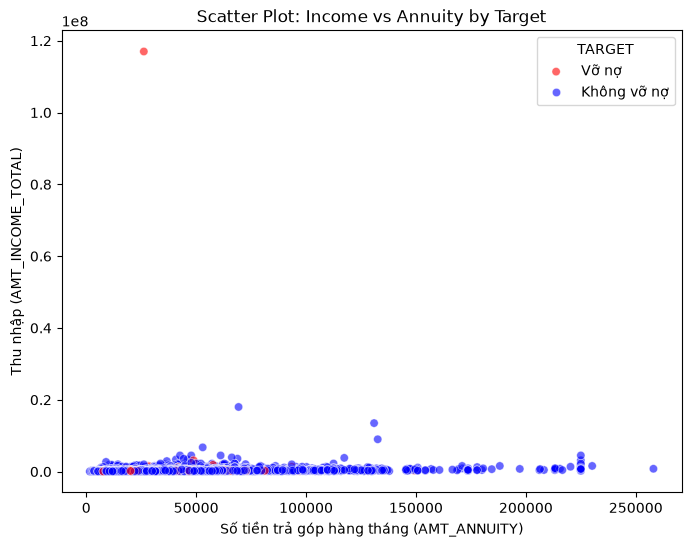

In [107]:
# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='AMT_ANNUITY',      # Trục Y: Số tiền trả góp hàng tháng
    y='AMT_INCOME_TOTAL',     # Trục X: Thu nhập        
    hue='TARGET',               # Màu sắc theo TARGET (0 = không vỡ nợ, 1 = vỡ nợ)
    palette={0: 'blue', 1: 'red'},  # Tùy chỉnh màu sắc
    alpha=0.6
)

plt.title('Scatter Plot: Income vs Annuity by Target')
plt.ylabel('Thu nhập (AMT_INCOME_TOTAL)')
plt.xlabel('Số tiền trả góp hàng tháng (AMT_ANNUITY)')
plt.legend(title='TARGET', labels=['Vỡ nợ','Không vỡ nợ'])
plt.show()

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\4138116187.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


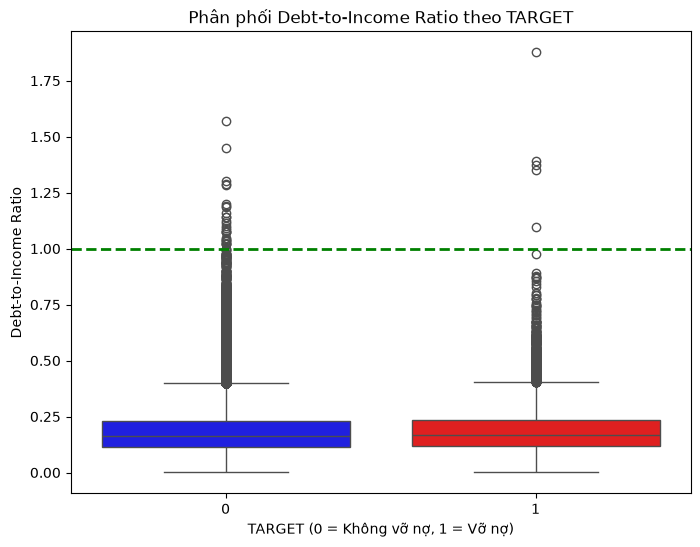

In [108]:
df['DTI'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'] #tỷ lệ nợ trên thu nhập.

# Vẽ Box Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='TARGET', 
    y='DTI',
    palette={'0': 'blue', '1': 'red'}  
)
plt.axhline(y=1, color = 'green', linestyle= '--',  linewidth=2, label='Ngưỡng DTI = 1')
plt.title('Phân phối Debt-to-Income Ratio theo TARGET')
plt.xlabel('TARGET (0 = Không vỡ nợ, 1 = Vỡ nợ)')
plt.ylabel('Debt-to-Income Ratio')
plt.show()

In [109]:
# Tạo biến nhóm áp lực nợ
df['DebtPressure'] = df['DTI'].apply(lambda x: 'Nợ <= 1' if x <= 1 else 'Nợ > 1')

# Vẽ biểu đồ
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='NAME_FAMILY_STATUS',
    y='TARGET',
    hue='DebtPressure',
    estimator='mean',   # lấy trung bình (tỷ lệ vỡ nợ)
    palette={'Nợ <= 1':'blue','Nợ > 1':'red'}
)

plt.title('Tỷ lệ vỡ nợ theo tình trạng hôn nhân và áp lực nợ')
plt.xlabel('Tình trạng hôn nhân (NAME_FAMILY_STATUS)')
plt.ylabel('Tỷ lệ vỡ nợ (Mean TARGET)')
plt.legend(title='Nhóm áp lực nợ')
plt.xticks(rotation=30)
plt.show()

ValueError: Could not interpret value `NAME_FAMILY_STATUS` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

---
## Biểu đồ 1: Phân phối Target
*Biểu đồ này cho thấy sự mất cân bằng nghiêm trọng giữa hai lớp: phần lớn khách hàng không vỡ nợ (Target=0), chỉ khoảng 8% vỡ nợ (Target=1). Đây là thách thức lớn cho mô hình dự đoán.*

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=df, palette='Set2')
plt.title('Phân phối biến mục tiêu TARGET')
plt.xlabel('TARGET (0 = Không vỡ nợ, 1 = Vỡ nợ)')
plt.ylabel('Số lượng khách hàng')
total = len(df)
for i, p in enumerate(plt.gca().patches):
    height = p.get_height()
    plt.text(p.get_x()+p.get_width()/2., height+2000,
             f'{height/total*100:.1f}%', ha='center', fontsize=11)
plt.show()

---
## Biểu đồ 2: Giá trị khuyết thiếu (Missing Values) - Top 20 cột
*Các cột có tỷ lệ khuyết thiếu cao (như `EXT_SOURCE_3`, `DAYS_LAST_PHONE_CHANGE`, `OWN_CAR_AGE`,...) cần được xử lý bằng điền giá trị hoặc loại bỏ trước khi huấn luyện mô hình.*

In [ ]:
missing = application_train.isnull().sum()
missing_pct = (missing / len(application_train)) * 100
missing_top = missing_pct.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
missing_top.plot(kind='bar', color='steelblue')
plt.title('Top 20 cột có tỷ lệ giá trị khuyết thiếu cao nhất')
plt.xlabel('Cột')
plt.ylabel('Tỷ lệ khuyết thiếu (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Biểu đồ 3: Histogram các biến số
*Histogram cho thấy hầu hết các biến số đều có phân phối lệch phải (skewness dương), đặc biệt là `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `DAYS_EMPLOYED`. Cần cân nhắc transform log hoặc box-cox.*

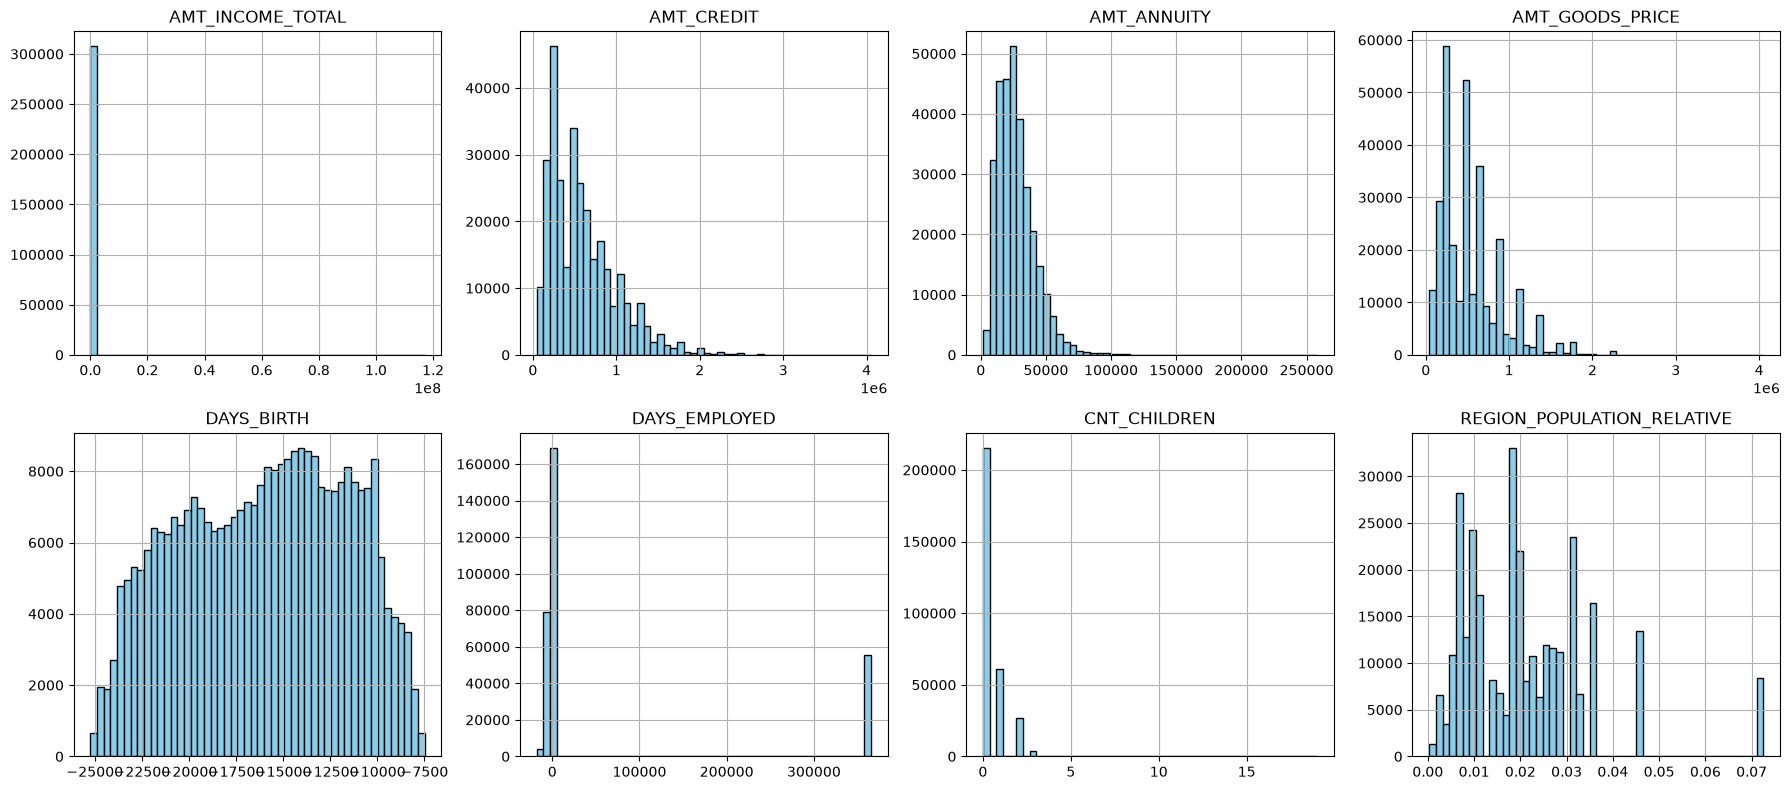

In [110]:
numeric_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
                'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
                'CNT_CHILDREN', 'REGION_POPULATION_RELATIVE']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for idx, col in enumerate(numeric_cols):
    if col in application_train.columns:
        application_train[col].hist(bins=50, ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(col, fontsize=12)
        axes[idx].set_xlabel('')
plt.tight_layout()
plt.show()

---
## Biểu đồ 4: Tương quan các biến với TARGET
*Biểu đồ cột thể hiện mức độ tương quan tuyến tính (Pearson) giữa các biến và TARGET. Các biến `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` có tương quan âm mạnh nhất, cho thấy khả năng dự báo tốt.*

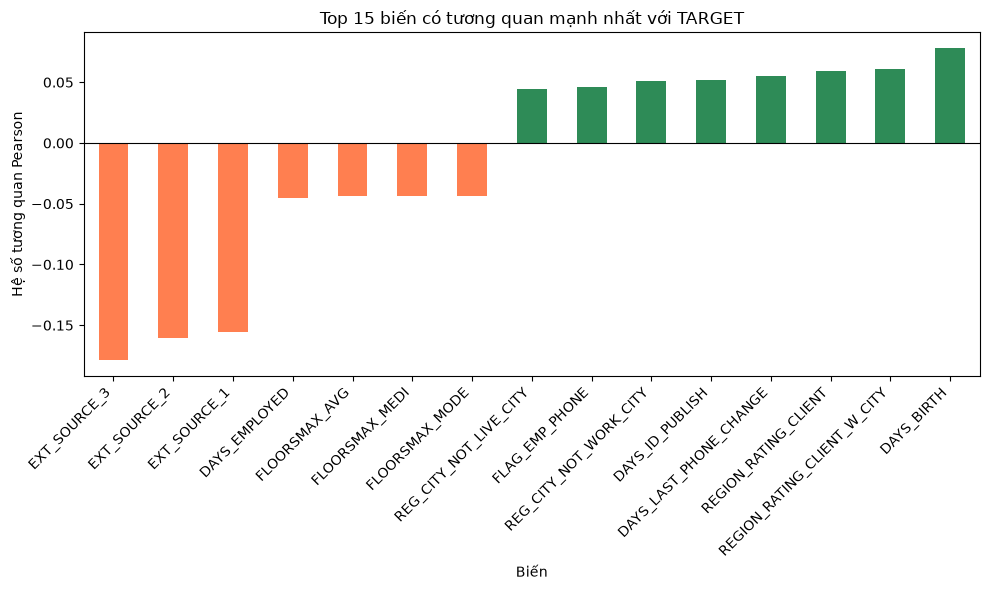

In [111]:
corr = application_train.corr(numeric_only=True)['TARGET'].drop('TARGET').sort_values()
top15 = pd.concat([corr.head(7), corr.tail(8)])

plt.figure(figsize=(10,6))
top15.plot(kind='bar', color=['coral' if v < 0 else 'seagreen' for v in top15.values])
plt.title('Top 15 biến có tương quan mạnh nhất với TARGET')
plt.xlabel('Biến')
plt.ylabel('Hệ số tương quan Pearson')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Biểu đồ 5: Boxplot EXT_SOURCE và DAYS_BIRTH theo TARGET
*Biểu đồ hộp cho thấy nhóm vỡ nợ (Target=1) có điểm `EXT_SOURCE` thấp hơn và tuổi trẻ hơn (`DAYS_BIRTH` gần 0 hơn) so với nhóm không vỡ nợ. Điều này gợi ý rằng khách hàng trẻ và có điểm tín dụng ngoài thấp có rủi ro cao hơn.*

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\2480401761.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y=col, data=application_train,
C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\2480401761.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y=col, data=application_train,
C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\2480401761.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y=col, data=application_train,
C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\2480401761.py:5: Futu

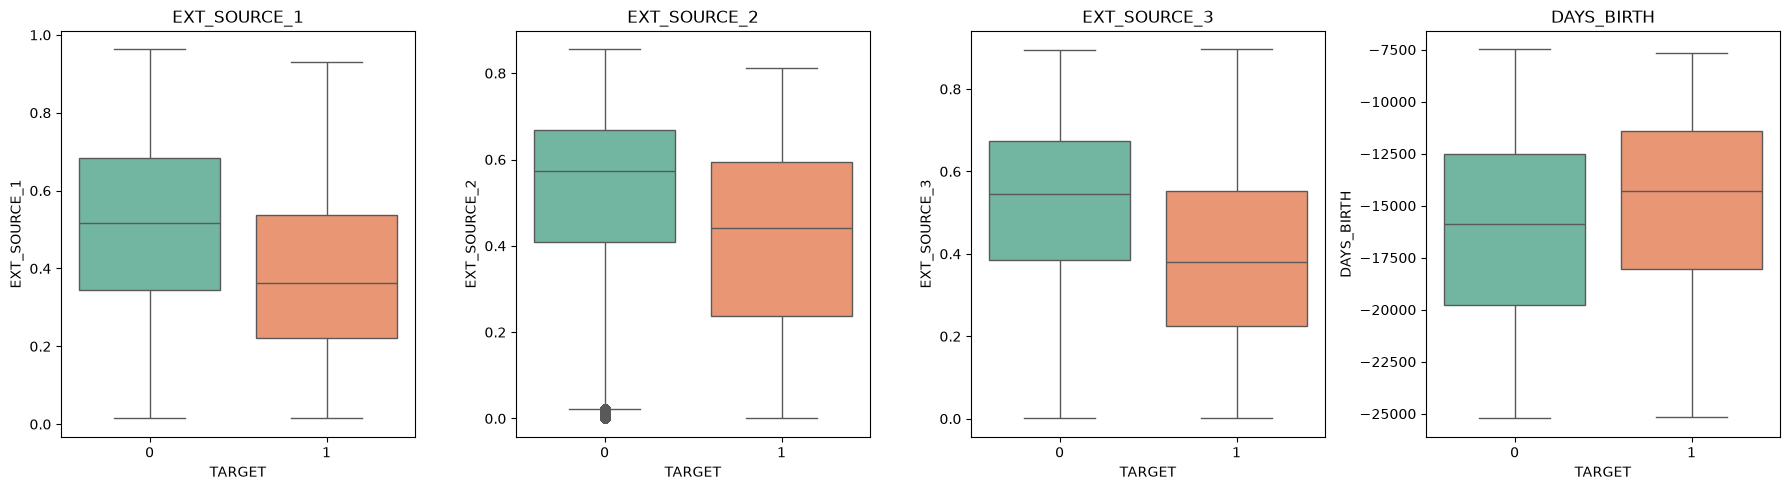

In [112]:
box_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for idx, col in enumerate(box_cols):
    if col in application_train.columns:
        sns.boxplot(x='TARGET', y=col, data=application_train,
                    palette='Set2', ax=axes[idx])
        axes[idx].set_title(col)
plt.tight_layout()
plt.show()

---
## Biểu đồ 6: Tỷ lệ vỡ nợ theo các biến phân loại
*Biểu đồ này thể hiện tỷ lệ vỡ nợ trung bình theo từng nhóm: Nam giới (`CODE_GENDER`) có tỷ lệ vỡ nợ cao hơn; học vấn thấp (`Lower secondary`) có rủi ro cao nhất; tình trạng hôn nhân "Singles" cũng có rủi ro cao hơn so với "Married".*

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\2568099024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='TARGET', data=application_train,
C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\2568099024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='TARGET', data=application_train,
C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\2568099024.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='TARGET', data=application_train,
C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_32940\2568099024.py:9: Futu

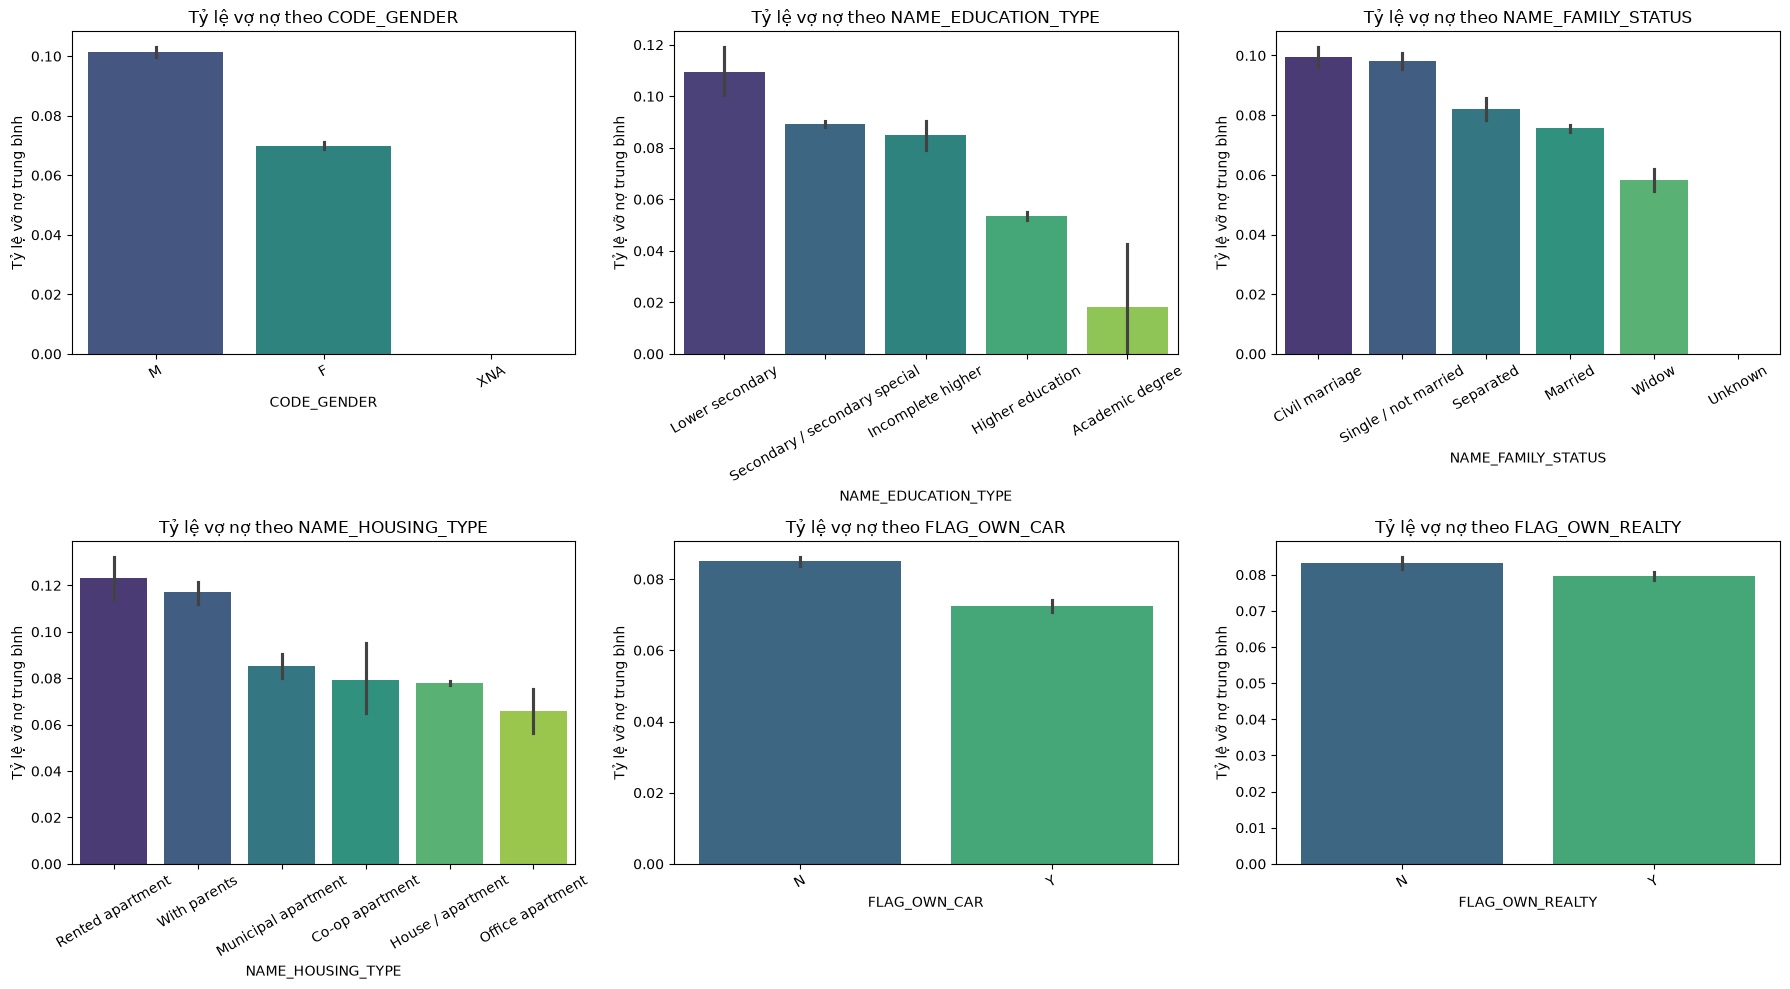

In [113]:
cat_cols = ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
            'NAME_HOUSING_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, col in enumerate(cat_cols):
    if col in application_train.columns:
        order = application_train.groupby(col)['TARGET'].mean().sort_values(ascending=False).index
        sns.barplot(x=col, y='TARGET', data=application_train,
                    order=order, estimator='mean', palette='viridis', ax=axes[idx])
        axes[idx].set_title(f'Tỷ lệ vợ nợ theo {col}')
        axes[idx].set_ylabel('Tỷ lệ vỡ nợ trung bình')
        axes[idx].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()